# Comparative Study of Models for Industrial Network Anomaly Detection

This notebook organizes the full case-study pipeline:

1. data loading;
2. construction of matrix representations (`len`, `idle`, and `composite`);
3. semi-controlled anomaly injection;
4. extraction of transition metrics between consecutive windows;
5. execution of multiple algorithms (online/incremental, classical, AutoML, and ANN);
6. consolidation of global results for the article.

The goal is to preserve **fair comparison** through a common evaluation protocol (temporal split and identical metrics for all models).


## 1) Imports and optional dependencies

- Main dependencies: `numpy`, `pandas`, `scikit-learn`, `scipy`, and `matplotlib`.
- The notebook tries to use `xgboost` and `torch` when available.
- If they are not installed, it falls back gracefully and reports that explicitly in the results.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.spatial.distance import jensenshannon

from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix, average_precision_score, precision_recall_fscore_support
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.ensemble import IsolationForest, RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.svm import OneClassSVM
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

from pathlib import Path
import sys
sys.path.append(str((Path.cwd() / '..' / 'src').resolve()))
from teda import TEDA

# xgboost (opcional)
try:
    from xgboost import XGBClassifier
    HAS_XGBOOST = True
except Exception:
    HAS_XGBOOST = False

# torch (opcional, para autoencoder mais pesado)
try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    HAS_TORCH = True
except Exception:
    HAS_TORCH = False



# pykan (opcional)
try:
    from kan import KAN
    HAS_KAN = True
except Exception:
    HAS_KAN = False

print('HAS_XGBOOST =', HAS_XGBOOST)
print('HAS_TORCH   =', HAS_TORCH)
print('HAS_KAN     =', HAS_KAN)


HAS_XGBOOST = True
HAS_TORCH   = True
HAS_KAN     = True


## 2) Experiment configuration

This section centralizes parameters to improve reproducibility and support article-oriented adjustments.

In [2]:
# Caminho do dataset bruto
DATA_PATH = '../data/raw/data_1.csv'

# Janela e baseline
WINDOW_SIZE = 500
STEP = 1
REF_WINDOWS = 300
Y_CLIP = 400
ALERT_QUANTILE = 0.995

# Injeção sintética semi-controlada
SEED = 42
INJECT_WARMUP = 20_000
N_SYNTH_EVENTS = 12
EVENT_MIN_LEN = 200
EVENT_MAX_LEN = 600
IDLE_CLUSTERS = 3

# TEDA
TEDA_THRESHOLD_BASE = 2.0
TEDA_THR_GRID = np.round(np.arange(1.8, 3.41, 0.2), 2)

# Métrica objetivo (para ranking)
OBJECTIVE_W_F1 = 1.00
OBJECTIVE_W_FAR = 0.35
OBJECTIVE_W_BACC = 0.25
OBJECTIVE_W_MISS = 0.20

# Saídas
OUT_DIR = '../outputs/article_case_study_final'
OUT_RESULTS_CSV = f'{OUT_DIR}/resultados_globais_modelos.csv'

# KAN
KAN_STEPS = 25
KAN_GRID = 3
KAN_K = 3
KAN_WIDTH_HIDDEN = 8
KAN_MAX_TRAIN_SAMPLES = 5000
KAN_OPT = 'LBFGS'



## 3) Helper functions

The functions below implement:

- temporal transformation (`time since last occurrence`);
- construction of 2D matrices per window;
- JSD and Frobenius computation;
- synthetic anomaly injection;
- construction of the composite representation (`len + idle class`);
- standardized metric and objective computation.

In [3]:
def time_since_last_occurrence(series):
    last_seen = {}
    y = np.empty(len(series), dtype=float)
    for idx, value in enumerate(series):
        if pd.isna(value):
            y[idx] = np.nan
            continue
        if value in last_seen:
            y[idx] = idx - last_seen[value]
        else:
            y[idx] = np.nan
        last_seen[value] = idx
    return y


def build_window_hist2d(
    X,
    y,
    window_size=500,
    step=20,
    x_bins=None,
    y_bins=None,
    y_log=False,
    y_clip=None,
):
    X = np.asarray(X)
    y = np.asarray(y)

    if x_bins is None:
        x_vals = np.unique(X[~pd.isna(X)])
    else:
        x_vals = np.asarray(x_bins)

    x_to_idx = {v: i for i, v in enumerate(x_vals)}

    y_work = y[~np.isnan(y)]
    if y_clip is not None:
        y_work = np.clip(y_work, 0, y_clip)
    if y_log:
        y_work = np.log1p(y_work)

    lo, hi = np.nanpercentile(y_work, 1), np.nanpercentile(y_work, 99)
    if not np.isfinite(lo):
        lo = 0.0
    if not np.isfinite(hi) or hi <= lo:
        hi = lo + 1.0

    if y_bins is None:
        y_edges = np.linspace(lo, hi, 25)
    else:
        y_edges = np.asarray(y_bins)

    starts = np.arange(0, len(X) - window_size + 1, step, dtype=int)
    H = np.zeros((len(starts), len(x_vals), len(y_edges) - 1), dtype=np.int32)

    for k, start in enumerate(starts):
        end = start + window_size
        Xw = X[start:end]
        yw = y[start:end]

        mask = ~pd.isna(Xw) & ~np.isnan(yw)
        Xw = Xw[mask]
        yw = yw[mask]

        if y_clip is not None:
            yw = np.clip(yw, 0, y_clip)
        if y_log:
            yw = np.log1p(yw)

        y_bin_idx = np.searchsorted(y_edges, yw, side='right') - 1
        valid = (y_bin_idx >= 0) & (y_bin_idx < (len(y_edges) - 1))
        Xw = Xw[valid]
        y_bin_idx = y_bin_idx[valid]

        for xv, yb in zip(Xw, y_bin_idx):
            idx = x_to_idx.get(xv)
            if idx is not None:
                H[k, idx, yb] += 1

    return H, x_vals, y_edges, starts


def normalize_window(Hw, eps=1e-12):
    Hw = Hw.astype(np.float32)
    s = Hw.sum()
    return Hw / max(s, eps)


def _zscore_from_ref(a, ref_windows=300, eps=1e-6):
    a = np.asarray(a, dtype=np.float32)
    r = a[:ref_windows]
    mu = float(np.mean(r))
    sd = float(np.std(r))
    return (a - mu) / max(sd, eps)


def jsd_scores(H, ref_windows=200, ref_mode='mean'):
    Href = H[:ref_windows].astype(np.float32)
    if ref_mode == 'mean':
        Pref = Href.mean(axis=0)
    elif ref_mode == 'median':
        Pref = np.median(Href, axis=0)
    else:
        raise ValueError("ref_mode must be 'mean' or 'median'")

    Pref = normalize_window(Pref).ravel()
    out = np.empty(H.shape[0], dtype=np.float32)

    for k in range(H.shape[0]):
        Pk = normalize_window(H[k]).ravel()
        out[k] = jsd_distance_safe(Pk, Pref)
    return out


def frobenius_scores(H, ref_windows=200, ref_mode='mean'):
    Href = H[:ref_windows].astype(np.float32)
    if ref_mode == 'mean':
        Pref = Href.mean(axis=0)
    elif ref_mode == 'median':
        Pref = np.median(Href, axis=0)
    else:
        raise ValueError("ref_mode must be 'mean' or 'median'")

    Pref = normalize_window(Pref)
    out = np.empty(H.shape[0], dtype=np.float32)

    for k in range(H.shape[0]):
        Pk = normalize_window(H[k])
        out[k] = np.linalg.norm(Pk - Pref)
    return out


def rare_mass_score_from_H(H, q=0.75, eps=1e-12):
    H = np.asarray(H)
    ny = H.shape[2]
    y_from = int(max(0, min(ny - 1, np.floor(q * ny))))
    num = H[:, :, y_from:].sum(axis=(1, 2)).astype(np.float32)
    den = H.sum(axis=(1, 2)).astype(np.float32)
    return num / np.maximum(den, eps)


def jsd_distance_safe(a, b, eps=1e-12):
    a = np.asarray(a, dtype=np.float32)
    b = np.asarray(b, dtype=np.float32)
    a = np.clip(a, eps, None)
    b = np.clip(b, eps, None)
    a = a / a.sum()
    b = b / b.sum()
    return float(jensenshannon(a, b))


def cosine_distance_safe(a, b, eps=1e-12):
    a = np.asarray(a, dtype=np.float32)
    b = np.asarray(b, dtype=np.float32)
    na = np.linalg.norm(a)
    nb = np.linalg.norm(b)
    if na <= eps and nb <= eps:
        return 0.0
    denom = max(float(na * nb), eps)
    sim = float(np.dot(a, b) / denom)
    sim = float(np.clip(sim, -1.0, 1.0))
    return 1.0 - sim


def pairwise_window_distance_features(H, ref_windows=300):
    H = np.asarray(H)
    n_windows = H.shape[0]

    js = np.zeros(n_windows, dtype=np.float32)
    fro = np.zeros(n_windows, dtype=np.float32)
    rare = np.zeros(n_windows, dtype=np.float32)
    cos = np.zeros(n_windows, dtype=np.float32)
    euclid = np.zeros(n_windows, dtype=np.float32)
    avg_pool = np.zeros(n_windows, dtype=np.float32)

    rare_mass = rare_mass_score_from_H(H, q=0.75)
    normalized = np.array([normalize_window(H[k]) for k in range(n_windows)], dtype=np.float32)

    for k in range(1, n_windows):
        prev = normalized[k - 1]
        curr = normalized[k]
        prev_flat = prev.ravel()
        curr_flat = curr.ravel()
        diff = curr - prev
        abs_diff = np.abs(diff)

        js[k] = jsd_distance_safe(prev_flat, curr_flat)
        fro[k] = np.linalg.norm(diff)
        rare[k] = abs(float(rare_mass[k]) - float(rare_mass[k - 1]))
        cos[k] = cosine_distance_safe(prev_flat, curr_flat)
        euclid[k] = np.linalg.norm(curr_flat - prev_flat)
        avg_pool[k] = float(abs_diff.mean())

    feats_mv = np.column_stack([
        _zscore_from_ref(js, ref_windows),
        _zscore_from_ref(fro, ref_windows),
        _zscore_from_ref(rare, ref_windows),
        _zscore_from_ref(cos, ref_windows),
        _zscore_from_ref(euclid, ref_windows),
        _zscore_from_ref(avg_pool, ref_windows),
    ]).astype(np.float32)

    feature_df = pd.DataFrame({
        'js': js,
        'fro': fro,
        'rare': rare,
        'cos': cos,
        'euclid': euclid,
        'avg_pool': avg_pool,
    })

    return {
        'js': js,
        'fro': fro,
        'rare': rare,
        'cos': cos,
        'euclid': euclid,
        'avg_pool': avg_pool,
        'mv_feats': feats_mv,
        'feature_df': feature_df,
    }


def build_legacy_teda_features(H, ref_windows=300):
    js = jsd_scores(H, ref_windows=ref_windows, ref_mode='mean')
    fro = frobenius_scores(H, ref_windows=ref_windows, ref_mode='mean')
    rare = rare_mass_score_from_H(H, q=0.75)
    d_js = np.diff(js, prepend=js[0])
    d_fro = np.diff(fro, prepend=fro[0])

    mv_feats = np.column_stack([
        _zscore_from_ref(js, ref_windows),
        _zscore_from_ref(fro, ref_windows),
        _zscore_from_ref(d_js, ref_windows),
        _zscore_from_ref(d_fro, ref_windows),
        _zscore_from_ref(rare, ref_windows),
    ]).astype(np.float32)

    return {
        'js': js,
        'fro': fro,
        'rare': rare,
        'd_js': d_js,
        'd_fro': d_fro,
        'mv_feats': mv_feats,
    }


def build_legacy_teda_variant_catalog(legacy_obj):
    catalog = []

    for name in ['js', 'fro']:
        series = np.asarray(legacy_obj[name], dtype=np.float32)
        catalog.append({
            'variante': name,
            'variante_base': name,
            'tipo': 'univariado',
            'normalizacao': 'raw',
            'features_usadas': [name],
            'n_features': 1,
            'values': series,
            'score': series,
            'protocolo': 'legacy',
        })

    mv = np.asarray(legacy_obj['mv_feats'], dtype=np.float32)
    catalog.append({
        'variante': 'mv',
        'variante_base': 'mv',
        'tipo': 'multivariado',
        'normalizacao': 'zscore',
        'features_usadas': ['js', 'fro', 'd_js', 'd_fro', 'rare'],
        'n_features': int(mv.shape[1]),
        'values': mv,
        'score': np.linalg.norm(mv, axis=1),
        'protocolo': 'legacy',
    })

    return catalog


def build_composite_token(df, n_clusters=3, random_state=42):
    idle = df['Idle(bit)'].to_numpy(dtype=float)
    length = df['Len(byte)'].to_numpy(dtype=float)

    mask = ~np.isnan(idle)
    km = KMeans(n_clusters=n_clusters, n_init=10, random_state=random_state)
    labels = np.full(len(idle), fill_value=-1, dtype=int)
    labels[mask] = km.fit_predict(idle[mask].reshape(-1, 1))

    centers = km.cluster_centers_.ravel()
    order = np.argsort(centers)
    remap = {old: new for new, old in enumerate(order)}
    idle_class = np.array([remap.get(v, -1) for v in labels], dtype=int)

    x_comp = np.empty(len(df), dtype=object)
    for i in range(len(df)):
        if np.isnan(length[i]) or idle_class[i] < 0:
            x_comp[i] = np.nan
        else:
            x_comp[i] = (int(length[i]), int(idle_class[i]))

    return x_comp, idle_class, np.sort(centers)


def inject_synthetic_anomalies(
    df,
    warmup=20_000,
    n_events=12,
    min_len=250,
    max_len=1200,
    seed=42,
):
    rng = np.random.default_rng(seed)

    out = df.copy()
    length = out['Len(byte)'].to_numpy(dtype=float)
    idle = out['Idle(bit)'].to_numpy(dtype=float)

    n = len(out)
    labels = np.zeros(n, dtype=np.uint8)
    used = np.zeros(n, dtype=bool)
    events = []

    l_min = np.nanmin(length)
    l_max = np.nanmax(length)
    i_min = np.nanmin(idle)
    i_max = np.nanmax(idle)

    len_hi = max(np.nanpercentile(length, 95), l_max * 0.85)
    idle_std = np.nanstd(idle)
    idle_center = np.nanpercentile(idle, 70)

    types = ['len_burst', 'idle_delay', 'period_shift', 'combined']
    gap = min_len // 2

    for i in range(n_events):
        t = types[i % len(types)]
        ev_len = int(rng.integers(min_len, max_len + 1))

        start, end = None, None
        for _ in range(4000):
            s = int(rng.integers(warmup, n - ev_len - 1))
            e = s + ev_len
            a = max(0, s - gap)
            b = min(n, e + gap)
            if not used[a:b].any():
                start, end = s, e
                break

        if start is None:
            continue

        used[start:end] = True
        labels[start:end] = 1

        if t == 'len_burst':
            length[start:end] = rng.choice([len_hi, l_max], size=ev_len, replace=True)
        elif t == 'idle_delay':
            factor = float(rng.uniform(2.0, 3.5))
            idle[start:end] = np.clip(idle[start:end] * factor, i_min, i_max)
        elif t == 'period_shift':
            noise = rng.normal(0, max(3.0, idle_std * 0.15), size=ev_len)
            idle[start:end] = np.clip(idle_center + noise, i_min, i_max)
            n_spikes = max(1, ev_len // 25)
            spike_pos = start + rng.choice(ev_len, size=n_spikes, replace=False)
            idle[spike_pos] = i_max
        elif t == 'combined':
            length[start:end] = rng.choice([len_hi, l_max], size=ev_len, replace=True)
            factor = float(rng.uniform(2.0, 3.0))
            idle[start:end] = np.clip(idle[start:end] * factor, i_min, i_max)

        events.append({'event_id': i, 'type': t, 'start': start, 'end': end, 'length': ev_len})

    out['Len(byte)'] = np.clip(np.rint(length), l_min, l_max)
    out['Idle(bit)'] = np.clip(np.rint(idle), i_min, i_max)

    events_df = pd.DataFrame(events).sort_values('start').reset_index(drop=True)
    return out, labels, events_df


def sample_to_window_labels(sample_labels, starts, window_size):
    sample_labels = np.asarray(sample_labels, dtype=np.uint8)
    starts = np.asarray(starts, dtype=int)
    csum = np.concatenate([[0], np.cumsum(sample_labels)])
    ends = np.minimum(starts + window_size, len(sample_labels))
    counts = csum[ends] - csum[starts]
    return counts > 0


def teda_flags(series, thr=2.0):
    s = np.asarray(series, dtype=np.float32)
    model = TEDA(threshold=thr)
    out = np.zeros(len(s), dtype=np.int8)
    for i, v in enumerate(s):
        out[i] = model.run(np.array([v], dtype=np.float32))
    return out.astype(bool)


def teda_flags_multivariate(features, thr=2.0):
    F = np.asarray(features, dtype=np.float32)
    model = TEDA(threshold=thr)
    out = np.zeros(F.shape[0], dtype=np.int8)
    for i in range(F.shape[0]):
        out[i] = model.run(F[i])
    return out.astype(bool)


def binary_metrics(y_true, flags, score=None):
    y_true = np.asarray(y_true, dtype=np.uint8)
    flags = np.asarray(flags, dtype=bool)

    tn, fp, fn, tp = confusion_matrix(y_true, flags.astype(np.uint8), labels=[0, 1]).ravel()

    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) else 0.0
    far = fp / (fp + tn) if (fp + tn) else 0.0

    accuracy = (tp + tn) / max(tp + tn + fp + fn, 1)
    tnr = tn / (tn + fp) if (tn + fp) else 0.0
    bacc = 0.5 * (recall + tnr)

    denom = np.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))
    mcc = ((tp * tn) - (fp * fn)) / denom if denom > 0 else 0.0

    ap = np.nan
    if score is not None:
        score = np.asarray(score, dtype=float)
        ap = average_precision_score(y_true, score)

    objective = (
        OBJECTIVE_W_F1 * f1
        - OBJECTIVE_W_FAR * far
        + OBJECTIVE_W_BACC * bacc
    )

    return {
        'precision': float(precision),
        'recall': float(recall),
        'f1': float(f1),
        'false_alarm_rate': float(far),
        'accuracy': float(accuracy),
        'balanced_accuracy': float(bacc),
        'mcc': float(mcc),
        'avg_precision': float(ap) if np.isfinite(ap) else np.nan,
        'objective_score': float(objective),
        'tp': int(tp),
        'fp': int(fp),
        'fn': int(fn),
        'tn': int(tn),
    }


def tune_threshold_from_scores(scores, y_true, idx_tune, quantiles=None):
    if quantiles is None:
        quantiles = np.linspace(0.90, 0.999, 40)

    best_thr = None
    best_metrics = None

    for q in quantiles:
        thr = float(np.quantile(scores[idx_tune], q))
        flags = scores > thr
        m = binary_metrics(y_true[idx_tune], flags[idx_tune], score=scores[idx_tune])
        if (
            best_metrics is None
            or m['objective_score'] > best_metrics['objective_score']
            or (m['objective_score'] == best_metrics['objective_score'] and m['f1'] > best_metrics['f1'])
        ):
            best_thr = thr
            best_metrics = m

    return best_thr, best_metrics


def tune_teda_threshold_univariate(series, y_true, idx_tune, thr_grid):
    best_thr = None
    best_metrics = None
    best_flags = None

    for thr in thr_grid:
        flags = teda_flags(series, thr=float(thr))
        m = binary_metrics(y_true[idx_tune], flags[idx_tune])
        if (
            best_metrics is None
            or m['objective_score'] > best_metrics['objective_score']
            or (m['objective_score'] == best_metrics['objective_score'] and m['f1'] > best_metrics['f1'])
        ):
            best_thr = float(thr)
            best_metrics = m
            best_flags = flags

    return best_thr, best_flags, best_metrics


def tune_teda_threshold_multivariate(features, y_true, idx_tune, thr_grid):
    best_thr = None
    best_metrics = None
    best_flags = None

    for thr in thr_grid:
        flags = teda_flags_multivariate(features, thr=float(thr))
        m = binary_metrics(y_true[idx_tune], flags[idx_tune])
        if (
            best_metrics is None
            or m['objective_score'] > best_metrics['objective_score']
            or (m['objective_score'] == best_metrics['objective_score'] and m['f1'] > best_metrics['f1'])
        ):
            best_thr = float(thr)
            best_metrics = m
            best_flags = flags

    return best_thr, best_flags, best_metrics


def build_representation_outputs(name, X, window_size, step, y_clip, ref_windows):
    y = time_since_last_occurrence(X)
    x_bins = np.unique(X[~pd.isna(X)])

    H, x_vals, y_edges, starts = build_window_hist2d(
        X,
        y,
        window_size=window_size,
        step=step,
        x_bins=x_bins,
        y_log=False,
        y_clip=y_clip,
    )

    pairwise = pairwise_window_distance_features(H, ref_windows=ref_windows)
    legacy_teda = build_legacy_teda_features(H, ref_windows=ref_windows)
    feature_df = pairwise['feature_df'].add_prefix(f'{name}_')

    return {
        'name': name,
        'starts': starts,
        'window_size': window_size,
        'H': H,
        'x_bins_count': len(x_vals),
        'y_bins_count': len(y_edges) - 1,
        'js': pairwise['js'],
        'fro': pairwise['fro'],
        'rare': pairwise['rare'],
        'cos': pairwise['cos'],
        'euclid': pairwise['euclid'],
        'avg_pool': pairwise['avg_pool'],
        'mv_feats': pairwise['mv_feats'],
        'feature_df': feature_df,
        'legacy_teda': legacy_teda,
    }




def build_common_feature_set_catalog(rep_obj):
    legacy_teda = rep_obj['legacy_teda']
    catalog = {
        'legacy_univar_js': {
            'subset_name': 'legacy_univar_js',
            'protocolo_features': 'legacy',
            'feature_names': ['js'],
            'X': np.asarray(legacy_teda['js'], dtype=np.float32).reshape(-1, 1),
            'n_features': 1,
        },
        'legacy_univar_fro': {
            'subset_name': 'legacy_univar_fro',
            'protocolo_features': 'legacy',
            'feature_names': ['fro'],
            'X': np.asarray(legacy_teda['fro'], dtype=np.float32).reshape(-1, 1),
            'n_features': 1,
        },
        'legacy_mv': {
            'subset_name': 'legacy_mv',
            'protocolo_features': 'legacy',
            'feature_names': ['js', 'fro', 'd_js', 'd_fro', 'rare'],
            'X': np.asarray(legacy_teda['mv_feats'], dtype=np.float32),
            'n_features': int(np.asarray(legacy_teda['mv_feats']).shape[1]),
        },
    }

    current_subsets = {
        'current_univar_js': ['js'],
        'current_univar_fro': ['fro'],
        'current_univar_rare': ['rare'],
        'current_univar_cos': ['cos'],
        'current_univar_euclid': ['euclid'],
        'current_univar_avg_pool': ['avg_pool'],
        'current_pair_js_fro': ['js', 'fro'],
        'current_pair_cos_euclid': ['cos', 'euclid'],
        'current_pair_rare_avg_pool': ['rare', 'avg_pool'],
        'current_geom_4': ['js', 'fro', 'cos', 'euclid'],
        'current_full_6': ['js', 'fro', 'rare', 'cos', 'euclid', 'avg_pool'],
    }

    for subset_name, feature_names in current_subsets.items():
        X = np.column_stack([
            np.asarray(rep_obj[name], dtype=np.float32) for name in feature_names
        ]).astype(np.float32)
        catalog[subset_name] = {
            'subset_name': subset_name,
            'protocolo_features': 'current',
            'feature_names': feature_names,
            'X': X,
            'n_features': len(feature_names),
        }

    return catalog

def build_teda_variant_catalog(rep_obj, ref_windows=300):
    feature_names = ['js', 'fro', 'rare', 'cos', 'euclid', 'avg_pool']
    multivariate_subsets = [
        ['js', 'fro'],
        ['cos', 'euclid'],
        ['rare', 'avg_pool'],
        ['js', 'fro', 'cos', 'euclid'],
        feature_names,
    ]

    catalog = []

    for name in feature_names:
        series = np.asarray(rep_obj[name], dtype=np.float32)
        catalog.append({
            'variante': name,
            'variante_base': name,
            'tipo': 'univariado',
            'normalizacao': 'raw',
            'features_usadas': [name],
            'n_features': 1,
            'values': series,
            'score': series,
            'protocolo': 'current',
        })

    for subset in multivariate_subsets:
        subset_name = '+'.join(subset)
        raw_features = np.column_stack([
            np.asarray(rep_obj[name], dtype=np.float32) for name in subset
        ]).astype(np.float32)
        zscore_features = np.column_stack([
            _zscore_from_ref(rep_obj[name], ref_windows) for name in subset
        ]).astype(np.float32)

        for normalization_name, features in [
            ('raw', raw_features),
            ('zscore', zscore_features),
        ]:
            catalog.append({
                'variante': f'{subset_name}__{normalization_name}',
                'variante_base': subset_name,
                'tipo': 'multivariado',
                'normalizacao': normalization_name,
                'features_usadas': subset,
                'n_features': len(subset),
                'values': features,
                'score': np.linalg.norm(features, axis=1),
                'protocolo': 'current',
            })

    return catalog


## 4) Data loading and initial checks

In [4]:
df_raw = pd.read_csv(DATA_PATH, sep=';')
required_cols = ['Len(byte)', 'Idle(bit)']
for c in required_cols:
    if c not in df_raw.columns:
        raise ValueError(f'Coluna obrigatoria ausente: {c}')

df_raw = df_raw[required_cols].copy()
print('Raw dataset shape:', df_raw.shape)
print(df_raw.head(3))

Raw dataset shape: (208125, 2)
   Len(byte)  Idle(bit)
0       15.0       39.0
1       13.0       44.0
2       15.0       39.0


Statistical summary (Len(byte) and Idle(bit))


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,missing,missing_%,unique
Len(byte),208124.0,19.729238,21.102504,3.0,3.0,3.0,13.0,15.0,15.0,79.0,119.0,119.0,1,0.0,18
Idle(bit),208124.0,55.108445,67.403770,11.0,13.0,13.0,38.0,39.0,42.0,310.0,319.0,355.0,1,0.0,64


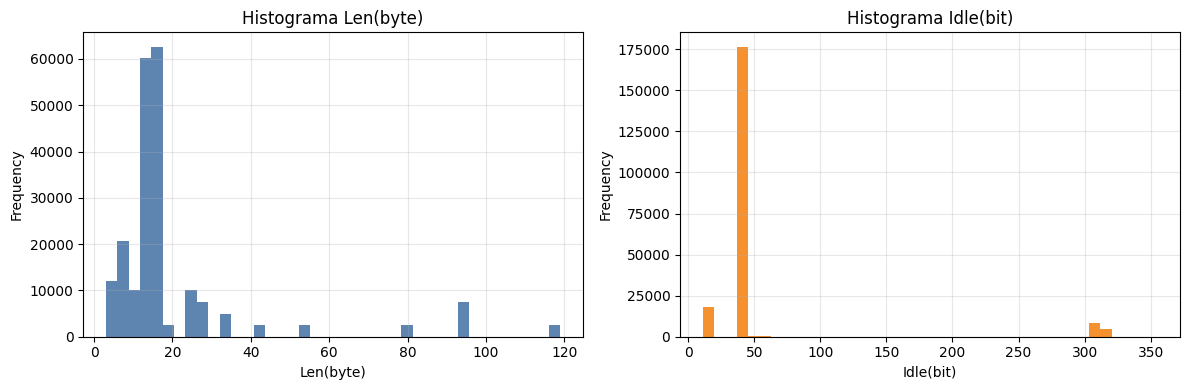

In [5]:
# --- Slide 1: visão geral dos dados ---
print('Statistical summary (Len(byte) and Idle(bit))')
stats_raw = df_raw.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T
stats_raw['missing'] = df_raw.isna().sum()
stats_raw['missing_%'] = (stats_raw['missing'] / len(df_raw) * 100).round(3)
stats_raw['unique'] = df_raw.nunique(dropna=True)
display(stats_raw)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_raw['Len(byte)'].dropna(), bins=40, color='#4C78A8', alpha=0.9)
axes[0].set_title('Histograma Len(byte)')
axes[0].set_xlabel('Len(byte)')
axes[0].set_ylabel('Frequency')
axes[0].grid(True, alpha=0.3)

axes[1].hist(df_raw['Idle(bit)'].dropna(), bins=40, color='#F58518', alpha=0.9)
axes[1].set_title('Histograma Idle(bit)')
axes[1].set_xlabel('Idle(bit)')
axes[1].set_ylabel('Frequency')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [6]:
# --- Exemplo: tempo desde a última ocorrência (head) ---
head_n = 10
tmp = df_raw.head(head_n).copy()
tmp['Len_last'] = time_since_last_occurrence(tmp['Len(byte)'])
tmp['Idle_last'] = time_since_last_occurrence(tmp['Idle(bit)'])
print('Sample with time since last occurrence:')
display(tmp)


Sample with time since last occurrence:


,Len(byte),Idle(bit),Len_last,Idle_last
0,15.0,39.0,NaN,NaN
1,13.0,44.0,NaN,NaN
2,15.0,39.0,2.0,2.0
3,13.0,44.0,2.0,2.0
4,15.0,39.0,2.0,2.0
5,16.0,40.0,NaN,NaN
6,32.0,39.0,NaN,2.0
7,16.0,40.0,2.0,2.0
8,32.0,39.0,2.0,2.0
9,11.0,41.0,NaN,NaN


## 5) Semi-controlled outlier injection

In this step we generate a set of synthetic events with different anomaly types:

- `len_burst`
- `idle_delay`
- `period_shift`
- `combined`

This creates a controlled ground truth for algorithm comparison.

In [7]:
df_synth, sample_labels, events_df = inject_synthetic_anomalies(
    df_raw,
    warmup=INJECT_WARMUP,
    n_events=N_SYNTH_EVENTS,
    min_len=EVENT_MIN_LEN,
    max_len=EVENT_MAX_LEN,
    seed=SEED,
)

print('Shape dataset sintetico:', df_synth.shape)
print('Total de eventos sinteticos:', len(events_df))
print('Anomalous samples (sample-level):', int(sample_labels.sum()))

events_df.head(12)

Shape dataset sintetico: (208125, 2)
Total de eventos sinteticos: 12
Anomalous samples (sample-level): 5222


,event_id,type,start,end,length
0,2,period_shift,37771,38222,451
1,8,len_burst,48677,48985,308
2,11,combined,55508,55996,488
3,5,idle_delay,67311,67626,315
4,10,period_shift,70783,71057,274
5,1,idle_delay,77952,78325,373
6,9,idle_delay,99742,100283,541
7,3,combined,142669,143254,585
8,4,len_burst,146305,146889,584
9,6,period_shift,159956,160450,494


In [8]:
# --- Slide 2: impacto da injeção de anomalias ---
print('Synthetic injection summary')
events_by_type = events_df['type'].value_counts()
display(events_by_type)

coverage = float(sample_labels.mean())
print(f'Anomalous sample coverage: {coverage:.2%}')
print('Event length distribution (samples):')
display(events_df[['length']].describe())

def quick_stats(df):
    return pd.DataFrame({
        'mean': df.mean(numeric_only=True),
        'median': df.median(numeric_only=True),
        'std': df.std(numeric_only=True),
        'p95': df.quantile(0.95, numeric_only=True),
    })

print('Before vs After (quick statistics)')
stats_before = quick_stats(df_raw)
stats_after = quick_stats(df_synth)
display(pd.concat({'before': stats_before, 'after': stats_after}, axis=1))

df_anom = df_synth[sample_labels == 1]
df_norm = df_synth[sample_labels == 0]
print('Normal vs Anomalous (quick statistics)')
display(pd.concat({'normal': quick_stats(df_norm), 'anomalous': quick_stats(df_anom)}, axis=1))


Synthetic injection summary


type
period_shift    3
len_burst       3
combined        3
idle_delay      3
Name: count, dtype: int64

Anomalous sample coverage: 2.51%
Event length distribution (samples):


,length
count,12.000000
mean,435.166667
std,128.663644
min,235.000000
25%,313.250000
50%,469.500000
75%,549.250000
max,585.000000


Before vs After (quick statistics)


before                               after                    \
                mean median        std    p95       mean median        std   
Len(byte)  19.729238   15.0  21.102504   79.0  20.925189   15.0  23.389683   
Idle(bit)  55.108445   39.0  67.403770  310.0  55.897143   39.0  67.674878   

                  
             p95  
Len(byte)   94.0  
Idle(bit)  310.0

Normal vs Anomalous (quick statistics)


normal                           anomalous                    \
                mean median        std    p95       mean median        std   
Len(byte)  19.724276   15.0  21.095821   79.0  67.586940  101.0  47.739577   
Idle(bit)  55.077530   39.0  67.343274  310.0  87.743393   79.0  72.665356   

                  
             p95  
Len(byte)  119.0  
Idle(bit)  310.0

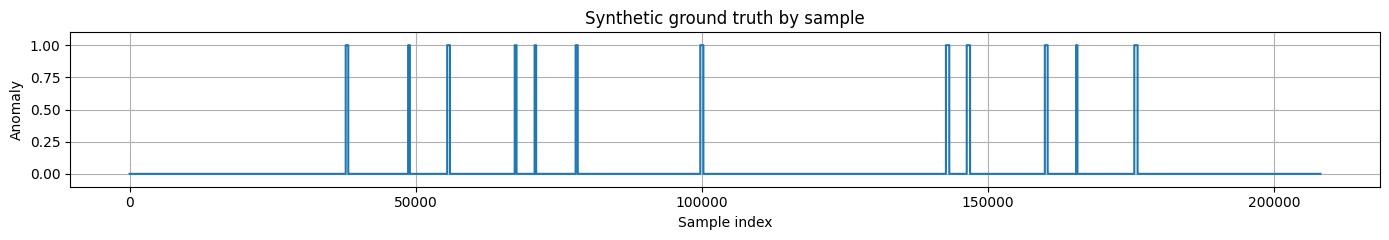

In [9]:
plt.figure(figsize=(14, 2.5))
plt.plot(sample_labels, drawstyle='steps-post')
plt.ylim(-0.1, 1.1)
plt.title('Synthetic ground truth by sample')
plt.xlabel('Sample index')
plt.ylabel('Anomaly')
plt.grid(True)
plt.tight_layout()
plt.show()

## 6) Construction of matrix representations

Three representations are built:

1. `len`: X = `Len(byte)`, y = time since last occurrence.
2. `idle`: X = `Idle(bit)`, y = time since last occurrence.
3. `composite`: X = `(Len(byte), idle_class)`, y = time since last occurrence.

Each representation generates a sequence of 2D matrices per window and six transition features computed between consecutive windows.


In [10]:
X_len = df_synth['Len(byte)'].to_numpy(dtype=float)
X_idle = df_synth['Idle(bit)'].to_numpy(dtype=float)
X_comp, idle_class, idle_centers = build_composite_token(
    df_synth,
    n_clusters=IDLE_CLUSTERS,
    random_state=SEED,
)

rep_len = build_representation_outputs('len', X_len, WINDOW_SIZE, STEP, Y_CLIP, REF_WINDOWS)
rep_idle = build_representation_outputs('idle', X_idle, WINDOW_SIZE, STEP, Y_CLIP, REF_WINDOWS)
rep_comp = build_representation_outputs('composite', X_comp, WINDOW_SIZE, STEP, Y_CLIP, REF_WINDOWS)

starts = rep_len['starts']
assert np.array_equal(starts, rep_idle['starts'])
assert np.array_equal(starts, rep_comp['starts'])

window_labels = sample_to_window_labels(sample_labels, starts, WINDOW_SIZE).astype(np.uint8)

print('Idle centers (clusters):', idle_centers)
print('Number of windows:', len(starts))
print('Anomalous windows:', int(window_labels.sum()))
print('Bins X (len/idle/composite):', rep_len['x_bins_count'], rep_idle['x_bins_count'], rep_comp['x_bins_count'])

Idle centers (clusters): [ 13.14864865  41.20327889 313.78355011]
Number of windows: 207626
Anomalous windows: 11210
Bins X (len/idle/composite): 19 142 51


## Features (equations and motivation)

Let $H_k$ be the 2D count matrix for window $k$ and $P_k = H_k / \sum H_k$ the normalized matrix.
All features are computed from the transition between consecutive windows, comparing $H_{k-1}$ and $H_k$.

- **JSD**: $JSD(P_{k-1}, P_k)$ measures the distribution change between consecutive windows.
- **Frobenius**: $\|P_k - P_{k-1}\|_F$ is the direct matrix distance between consecutive windows.
- **Rare mass**: $|\mathrm{rare}(H_k) - \mathrm{rare}(H_{k-1})|$ measures how much the mass in the high bins changes.
- **Cosine**: cosine distance between `flatten(P_{k-1})` and `flatten(P_k)`.
- **Euclidean**: Euclidean distance between `flatten(P_{k-1})` and `flatten(P_k)`.
- **Average pooling**: mean of $|P_k - P_{k-1}|$, yielding a scalar transition summary.

Motivation: JSD/Fro capture **global changes** in the distribution; rare mass tracks **tail variation**; cosine and Euclidean compare flattened profiles; average pooling summarizes the overall absolute shift.


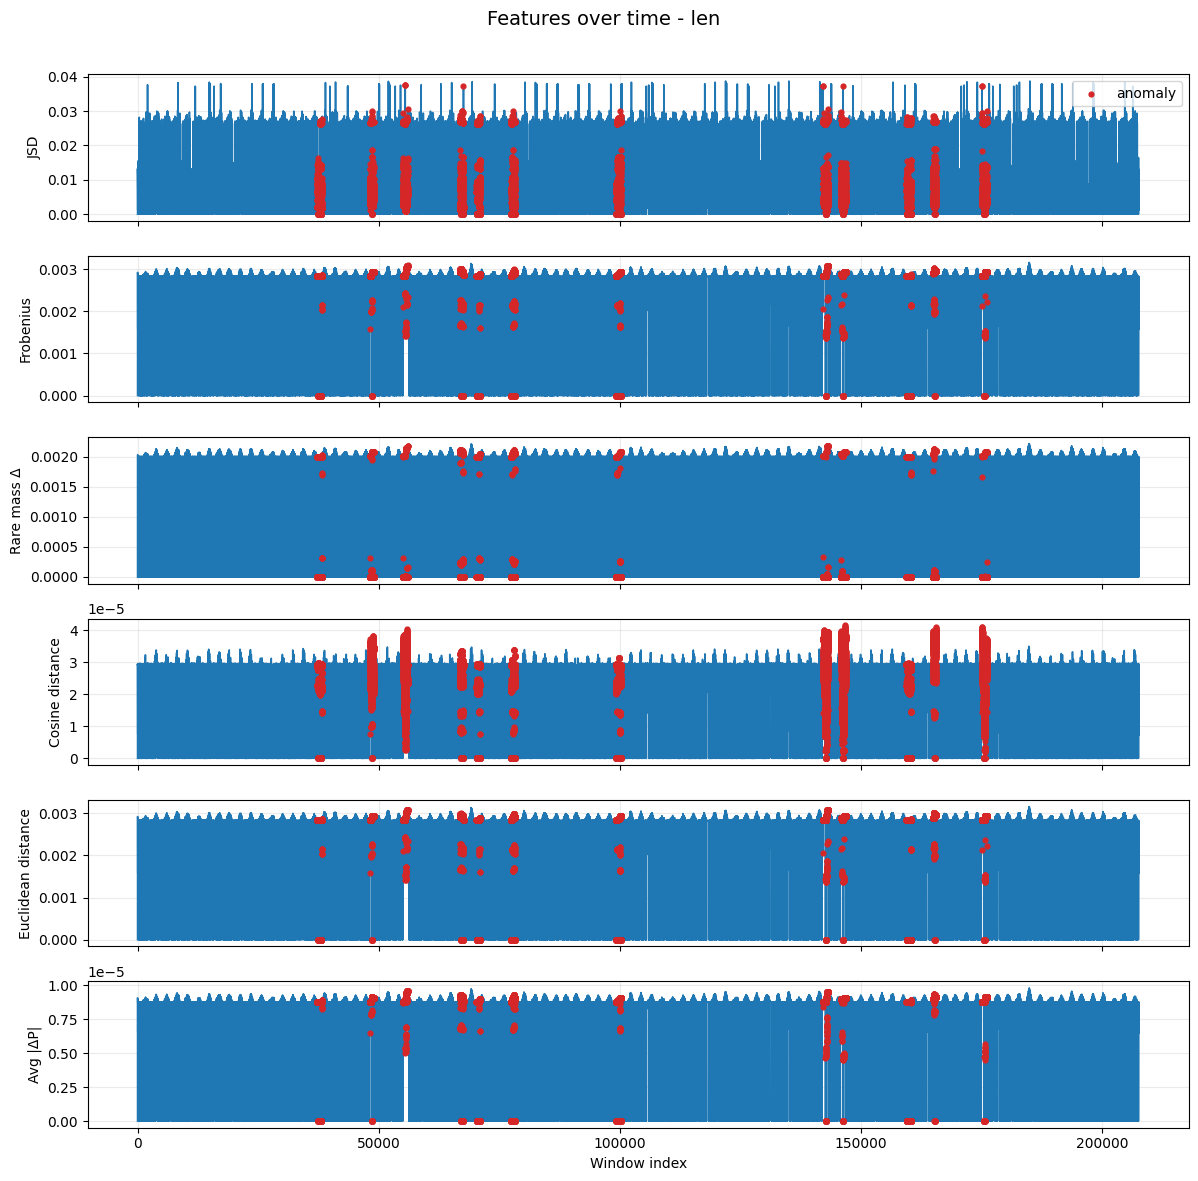

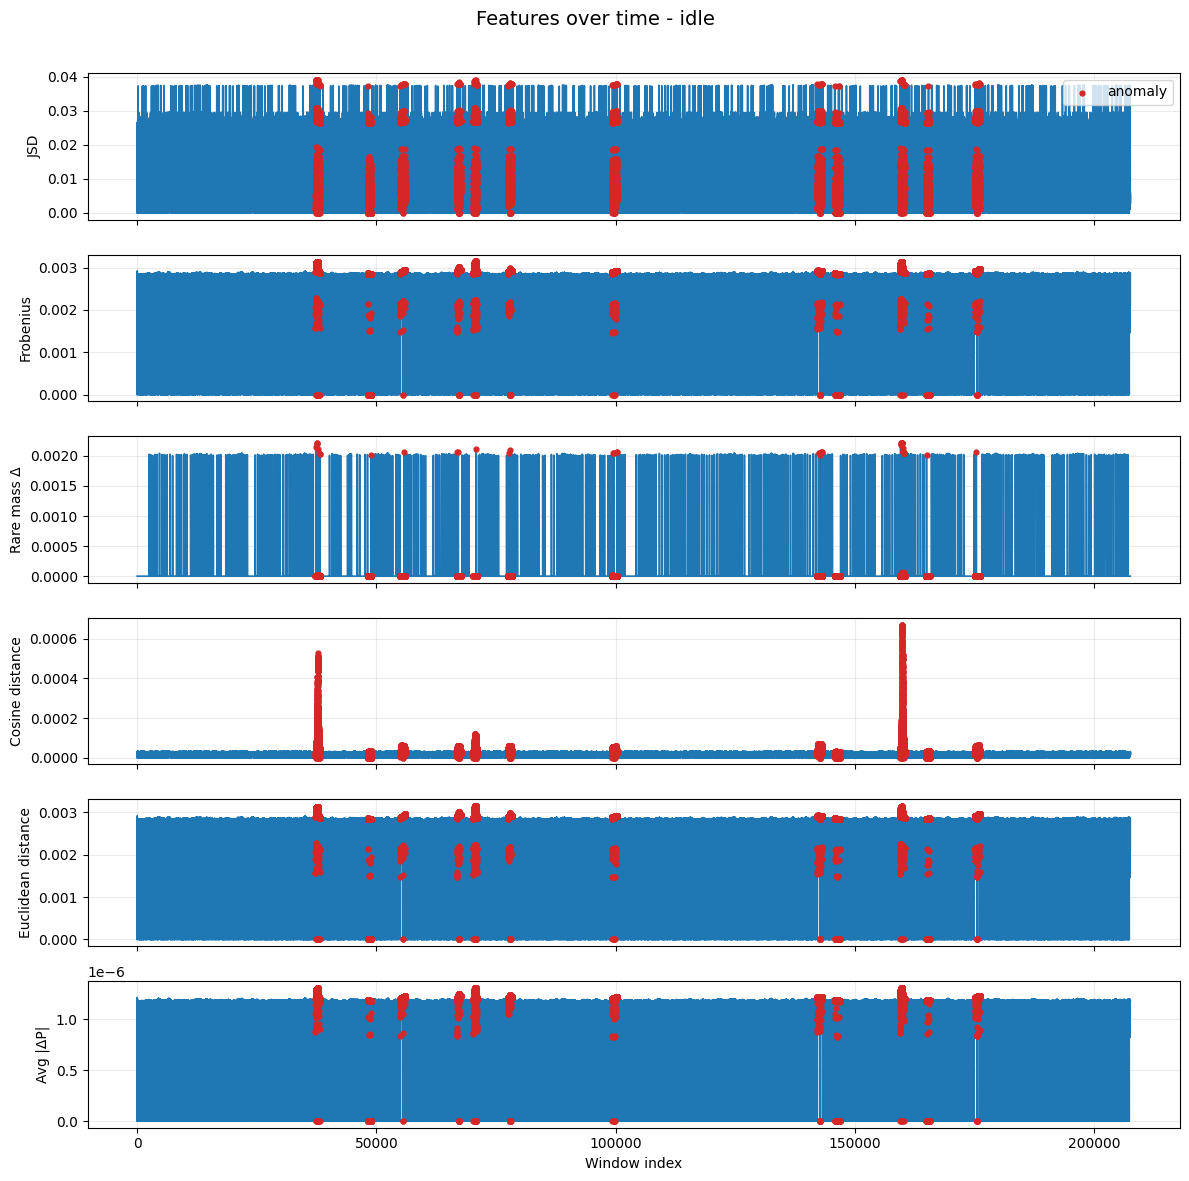

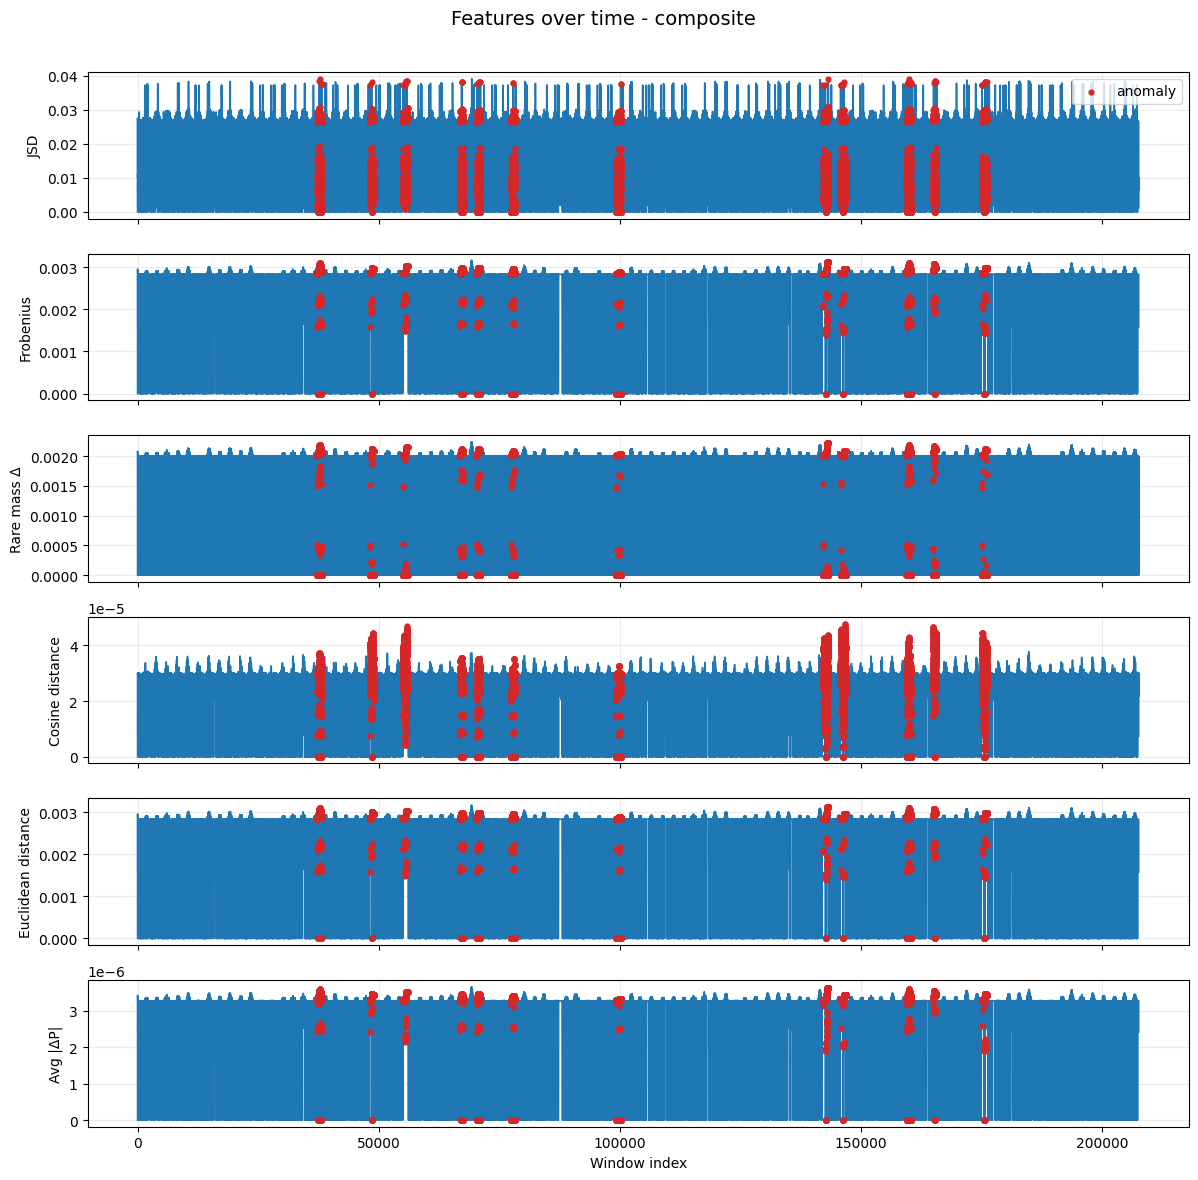

In [11]:
# --- Plots das features com anomalias (todas as representações) ---
reps = {
    'len': rep_len,
    'idle': rep_idle,
    'composite': rep_comp,
}

feature_keys = ['js', 'fro', 'rare', 'cos', 'euclid', 'avg_pool']
feature_labels = {
    'js': 'JSD',
    'fro': 'Frobenius',
    'rare': 'Rare mass Δ',
    'cos': 'Cosine distance',
    'euclid': 'Euclidean distance',
    'avg_pool': 'Avg |ΔP|',
}

for rep_name, rep_obj in reps.items():
    fig, axes = plt.subplots(len(feature_keys), 1, figsize=(12, 12), sharex=True)
    fig.suptitle(f'Features over time - {rep_name}', fontsize=14)
    x = np.arange(len(rep_obj['js']))
    anom_idx = np.where(window_labels.astype(bool))[0]

    for ax, fk in zip(axes, feature_keys):
        y = rep_obj[fk]
        ax.plot(x, y, color='#1f77b4', linewidth=1.2)
        if len(anom_idx):
            ax.scatter(anom_idx, y[anom_idx], color='#d62728', s=12, label='anomaly', zorder=3)
        ax.set_ylabel(feature_labels[fk], fontsize=10)
        ax.grid(True, alpha=0.25)

    axes[-1].set_xlabel('Window index')
    if len(anom_idx):
        axes[0].legend(loc='upper right')
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()


{
  "idx": 0,
  "Len(byte)": 15,
  "Idle(bit)": 39
}
Len matrix (window 0): (19, 24) | x_bins = 19 | y_bins = 24


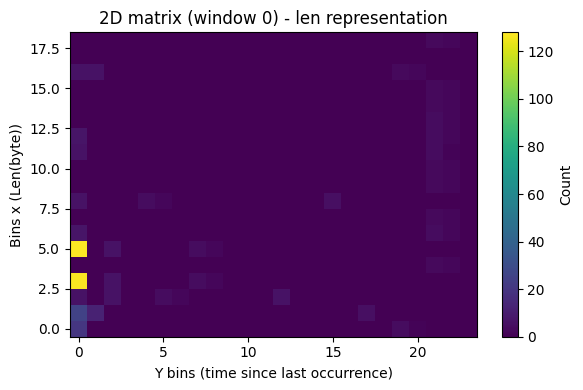

In [12]:
# --- Slide 3: exemplo de entrada (json) e matriz ---
import json
valid_rows = df_synth.dropna()
sample_idx = int(valid_rows.index[0]) if len(valid_rows) else 0
sample_row = df_synth.loc[sample_idx]
sample_json = {
    'idx': sample_idx,
    'Len(byte)': int(sample_row['Len(byte)']),
    'Idle(bit)': int(sample_row['Idle(bit)']),
}
print(json.dumps(sample_json, indent=2, ensure_ascii=False))

H_example = rep_len['H'][0]
print('Len matrix (window 0):', H_example.shape, '| x_bins =', rep_len['x_bins_count'], '| y_bins =', rep_len['y_bins_count'])
plt.figure(figsize=(6, 4))
plt.imshow(H_example, aspect='auto', origin='lower', cmap='viridis')
plt.title('2D matrix (window 0) - len representation')
plt.xlabel('Y bins (time since last occurrence)')
plt.ylabel('Bins x (Len(byte))')
plt.colorbar(label='Count')
plt.tight_layout()
plt.show()


Count without binning (raw table):


col_0,0,1,2,3,4,5,6,7,8,9,...,76,77,78,79,80,81,82,83,84,85
row_0,,,,,,,,,,,,,,,,,,,,,
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,16,4,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
116,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
117,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Quick view slice (0..15 x 0..15):


col_0,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
row_0,,,,,,,,,,,,,,,,
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,16,4,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
6,0,5,20,0,0,12,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


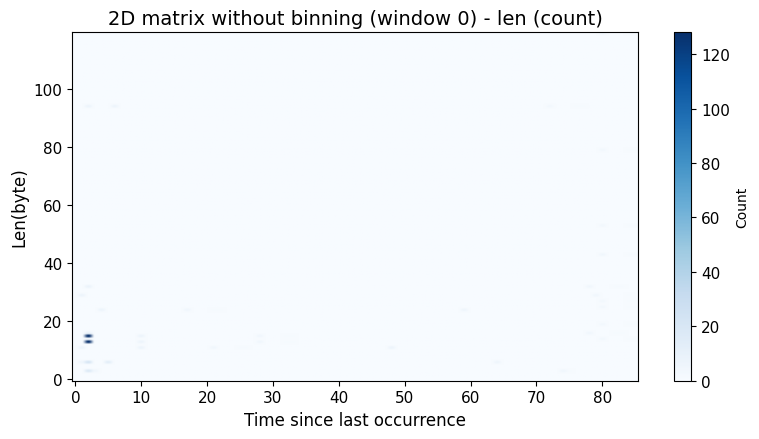

In [13]:
# --- Matriz sem binning (valores brutos) ---
NORMALIZE_VIEW = False  # True para visualizar contagens normalizadas por janela

X_len = df_synth['Len(byte)'].to_numpy(dtype=float)
y_len = time_since_last_occurrence(X_len)
start = int(rep_len['starts'][0])
end = start + int(rep_len['window_size'])
Xw = X_len[start:end]
yw = y_len[start:end]
mask = ~pd.isna(Xw) & ~np.isnan(yw)
Xw = Xw[mask].astype(int)
yw = yw[mask].astype(int)

count_raw = pd.crosstab(Xw, yw)

# Expande para mostrar todos os valores possíveis (ex.: 0..max)
max_x = int(Xw.max()) if len(Xw) else 0
max_y = int(yw.max()) if len(yw) else 0
count_raw = count_raw.reindex(index=range(0, max_x + 1), columns=range(0, max_y + 1), fill_value=0)

print('Count without binning (raw table):')
display(count_raw)

print('Quick view slice (0..15 x 0..15):')
display(count_raw.iloc[:16, :16])

from matplotlib import colors
plt.figure(figsize=(8, 4.5), facecolor='white')
ax = plt.gca()
ax.set_facecolor('white')

data_plot = count_raw.values.astype(float)
if NORMALIZE_VIEW:
    total = data_plot.sum()
    if total > 0:
        data_plot = data_plot / total

    vmax = np.percentile(data_plot, 99) if data_plot.size else 1
    norm = colors.PowerNorm(gamma=0.4, vmin=0, vmax=max(vmax, 1e-9))
    cbar_label = 'Proportion'
else:
    # Count bruta: escala linear (sem PowerNorm) para evitar e-9
    norm = None
    cbar_label = 'Count'

plt.imshow(data_plot, aspect='auto', origin='lower', cmap='Blues', norm=norm)
title_suffix = ' (normalized)' if NORMALIZE_VIEW else ' (count)'
plt.title('2D matrix without binning (window 0) - len' + title_suffix, fontsize=14)
plt.xlabel('Time since last occurrence', fontsize=12)
plt.ylabel('Len(byte)', fontsize=12)
cbar = plt.colorbar(label=cbar_label)
cbar.ax.tick_params(labelsize=11)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()


Max Len(byte) in window: 119 | Max time since last occurrence: 85


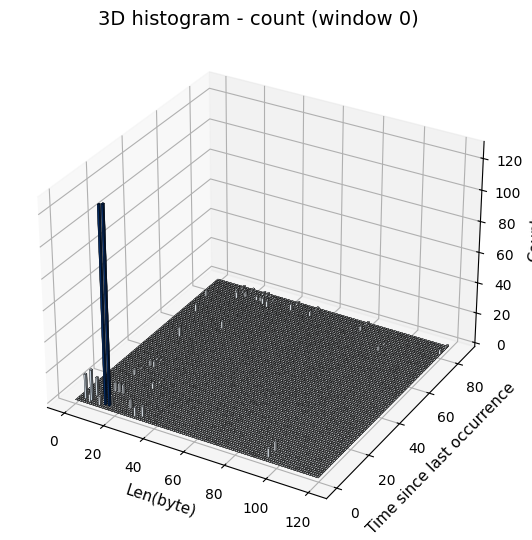

In [14]:
# --- Histograma 3D (contagem Len x tempo desde última ocorrência) ---
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# Usa a mesma matriz (bruta) para o histograma 3D
Z = count_raw.values.astype(float)

# Usa o tamanho real máximo da janela
max_x = Z.shape[0] - 1
max_y = Z.shape[1] - 1
print(f'Max Len(byte) in window: {max_x} | Max time since last occurrence: {max_y}')

x = np.arange(Z.shape[0])
y = np.arange(Z.shape[1])
xx, yy = np.meshgrid(x, y, indexing='ij')
xpos = xx.ravel()
ypos = yy.ravel()
zpos = np.zeros_like(xpos)
dx = 0.8 * np.ones_like(zpos)
dy = 0.8 * np.ones_like(zpos)
dz = Z.ravel()

fig = plt.figure(figsize=(9, 5.5), facecolor='white')
ax = fig.add_subplot(111, projection='3d')
ax.set_facecolor('white')

# Cores em gradiente pelo valor (azulado)
if dz.max() > 0:
    colors_norm = (dz - dz.min()) / (dz.max() - dz.min() + 1e-9)
else:
    colors_norm = dz
colors_map = plt.cm.Blues(colors_norm)

ax.bar3d(xpos, ypos, zpos, dx, dy, dz, color=colors_map, shade=True, edgecolor='k', linewidth=0.2)
ax.set_title('3D histogram - count (window 0)', fontsize=14)
ax.set_xlabel('Len(byte)', fontsize=11)
ax.set_ylabel('Time since last occurrence', fontsize=11)
ax.set_zlabel('Count', fontsize=11)

plt.tight_layout()
plt.show()


In [15]:
# --- Histogramas 3D por representação (len, idle, composite) sem binning ---
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

def _to_int_codes(arr):
    # Para valores numéricos, converte direto; para tuplas/objetos, usa codificação discreta
    try:
        return arr.astype(int), None
    except Exception:
        codes, uniques = pd.factorize(arr)
        return codes.astype(int), uniques

def plot_3d_hist_from_raw(X, title, window_start, window_size):
    y = time_since_last_occurrence(X)
    start = int(window_start)
    end = start + int(window_size)
    Xw = X[start:end]
    yw = y[start:end]
    mask = ~pd.isna(Xw) & ~np.isnan(yw)
    Xw = Xw[mask]
    yw = yw[mask]

    X_codes, X_uniques = _to_int_codes(np.asarray(Xw))
    yw = yw.astype(int)

    count_raw = pd.crosstab(X_codes, yw)
    max_x = int(X_codes.max()) if len(X_codes) else 0
    max_y = int(yw.max()) if len(yw) else 0
    count_raw = count_raw.reindex(index=range(0, max_x + 1), columns=range(0, max_y + 1), fill_value=0)

    Z = count_raw.values.astype(float)
    x = np.arange(Z.shape[0])
    yv = np.arange(Z.shape[1])
    xx, yy = np.meshgrid(x, yv, indexing='ij')
    xpos = xx.ravel()
    ypos = yy.ravel()
    zpos = np.zeros_like(xpos)
    dx = 0.8 * np.ones_like(zpos)
    dy = 0.8 * np.ones_like(zpos)
    dz = Z.ravel()

    fig = plt.figure(figsize=(9, 5.5), facecolor='white')
    ax = fig.add_subplot(111, projection='3d')
    ax.set_facecolor('white')

    if dz.max() > 0:
        colors_norm = (dz - dz.min()) / (dz.max() - dz.min() + 1e-9)
    else:
        colors_norm = dz
    colors_map = plt.cm.Blues(colors_norm)

    ax.bar3d(xpos, ypos, zpos, dx, dy, dz, color=colors_map, shade=True, edgecolor='k', linewidth=0.2)
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('X (raw value / code)', fontsize=11)
    ax.set_ylabel('Last occurrence', fontsize=11)
    ax.set_zlabel('Count', fontsize=11)
    plt.tight_layout()
    plt.show()

window_start = rep_len['starts'][0]
window_size = rep_len['window_size']

# plot_3d_hist_from_raw(X_len, 'Histograma 3D - len', window_start, window_size)
# plot_3d_hist_from_raw(X_idle, 'Histograma 3D - idle', window_start, window_size)
# plot_3d_hist_from_raw(X_comp, 'Histograma 3D - composite', window_start, window_size)


In [16]:
# --- Exemplo de contagem: dado bruto vs matriz ---
print('Raw data (head):')
display(df_raw.head())

# Primeira janela: mostra um recorte pequeno da matriz de contagem
H_example = rep_len['H'][0]
x_vals = np.unique(df_synth['Len(byte)'].dropna())
y_edges = None
# Usa os bins do próprio rep_len
y_edges = rep_len.get('y_edges', None)
# Fallback: reconstruir bordas aproximadas do H (apenas para exibição)
if y_edges is None:
    y_edges = np.linspace(0, Y_CLIP, H_example.shape[1] + 1)

# Recorte pequeno para visualização
x_slice = slice(0, min(6, H_example.shape[0]))
y_slice = slice(0, min(8, H_example.shape[1]))
H_small = H_example[x_slice, y_slice]

df_count = pd.DataFrame(H_small)
df_count.index.name = 'x_bin(Len)'
df_count.columns = [f'y_bin_{i}' for i in range(df_count.shape[1])]
print('Count matrix (slice):')
display(df_count.head())


Raw data (head):


,Len(byte),Idle(bit)
0,15.0,39.0
1,13.0,44.0
2,15.0,39.0
3,13.0,44.0
4,15.0,39.0


Count matrix (slice):


,y_bin_0,y_bin_1,y_bin_2,y_bin_3,y_bin_4,y_bin_5,y_bin_6,y_bin_7
x_bin(Len),,,,,,,,
0,20,0,0,0,0,0,0,0
1,25,12,0,0,0,0,0,0
2,6,0,6,0,0,4,2,0
3,127,0,6,0,0,0,0,4
4,0,0,0,0,0,0,0,0


In [17]:
# --- Slide 4: como as matrizes viram features ---
feature_desc = pd.DataFrame({
    'feature': ['js', 'fro', 'rare', 'cos', 'euclid', 'avg_pool'],
    'descricao': [
        'Jensen-Shannon distance between consecutive windows',
        'Frobenius norm between consecutive normalized matrices',
        'Absolute change in rare-bin mass between consecutive windows',
        'Cosine distance between flattened consecutive matrices',
        'Euclidean distance between flattened consecutive matrices',
        'Mean absolute difference between consecutive normalized matrices',
    ],
})
display(feature_desc)

print('Example of generated columns (len):', list(rep_len['feature_df'].columns))
print('Note: multivariate TEDA uses the standardized (z-score) versions of these features.')


,feature,descricao
0,js,Jensen-Shannon distance between consecutive wi...
1,fro,Frobenius norm between consecutive normalized ...
2,rare,Absolute change in rare-bin mass between conse...
3,cos,Cosine distance between flattened consecutive ...
4,euclid,Euclidean distance between flattened consecuti...
5,avg_pool,Mean absolute difference between consecutive n...


Example of generated columns (len): ['len_js', 'len_fro', 'len_rare', 'len_cos', 'len_euclid', 'len_avg_pool']
Note: multivariate TEDA uses the standardized (z-score) versions of these features.


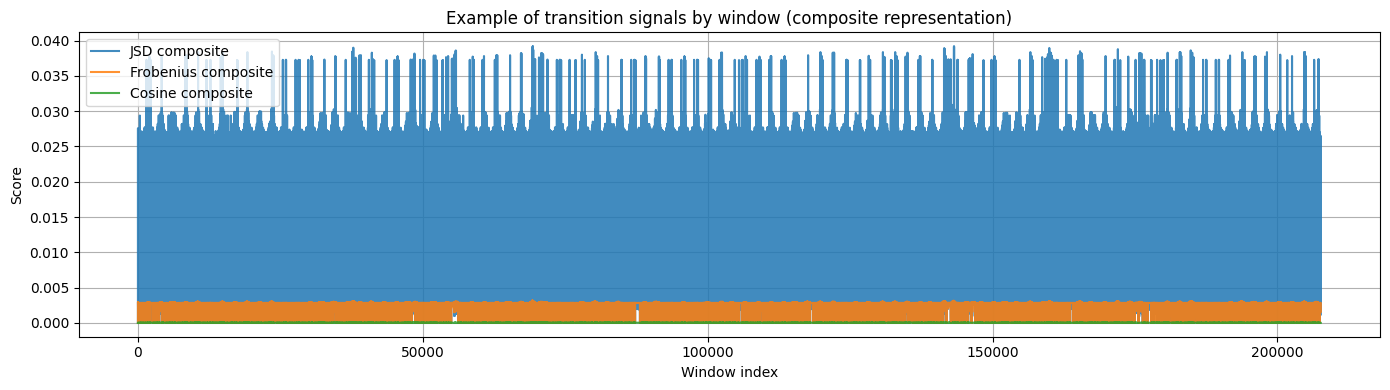

In [18]:
plt.figure(figsize=(14, 4))
plt.plot(rep_comp['js'], label='JSD composite', alpha=0.85)
plt.plot(rep_comp['fro'], label='Frobenius composite', alpha=0.85)
plt.plot(rep_comp['cos'], label='Cosine composite', alpha=0.85)
plt.title('Example of transition signals by window (composite representation)')
plt.xlabel('Window index')
plt.ylabel('Score')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## 7) Feature assembly by representation

Each algorithm is evaluated separately in **three configurations**:

1. `len`
2. `idle`
3. `composite`

The concatenated global configuration is not used in this version.


In [19]:
feature_sets_by_rep = {
    'len': build_common_feature_set_catalog(rep_len),
    'idle': build_common_feature_set_catalog(rep_idle),
    'composite': build_common_feature_set_catalog(rep_comp),
}

feature_set_names_by_rep = {
    rep_name: {
        subset_name: subset_obj['feature_names']
        for subset_name, subset_obj in subset_catalog.items()
    }
    for rep_name, subset_catalog in feature_sets_by_rep.items()
}

y_windows = window_labels.copy()

print('Feature sets por representacao:')
for rep_name, subset_catalog in feature_sets_by_rep.items():
    print(f'  {rep_name}: {len(subset_catalog)} subsets')

print('Window labels shape:', y_windows.shape)
print('Exemplo subsets len:', list(feature_sets_by_rep['len'].keys()))
print('Exemplo current_full_6 len:', feature_sets_by_rep['len']['current_full_6']['X'].shape)


Feature sets por representacao:
  len: 14 subsets
  idle: 14 subsets
  composite: 14 subsets
Window labels shape: (207626,)
Exemplo subsets len: ['legacy_univar_js', 'legacy_univar_fro', 'legacy_mv', 'current_univar_js', 'current_univar_fro', 'current_univar_rare', 'current_univar_cos', 'current_univar_euclid', 'current_univar_avg_pool', 'current_pair_js_fro', 'current_pair_cos_euclid', 'current_pair_rare_avg_pool', 'current_geom_4', 'current_full_6']
Exemplo current_full_6 len: (207626, 6)


## 8) Temporal evaluation protocol

To avoid temporal leakage and keep the comparison fair:

- `baseline` (start): used to fit the reference for unsupervised models;
- `tune`: used for threshold tuning;
- `test`: used for the final comparison across algorithms.

All models report metrics on the same `test` segment.

In [20]:
n_w = len(y_windows)
baseline_end = REF_WINDOWS
tune_end = int(0.60 * n_w)

if tune_end <= baseline_end + 100:
    raise ValueError('The tune segment became too short. Adjust REF_WINDOWS/STEP.')

idx_baseline = np.arange(0, baseline_end)
idx_tune = np.arange(baseline_end, tune_end)
idx_test = np.arange(tune_end, n_w)
idx_pretest = np.arange(0, tune_end)

print('n_windows:', n_w)
print('baseline:', idx_baseline[0], '->', idx_baseline[-1], f'({len(idx_baseline)})')
print('tune    :', idx_tune[0], '->', idx_tune[-1], f'({len(idx_tune)})')
print('test    :', idx_test[0], '->', idx_test[-1], f'({len(idx_test)})')
print('Anomaly prevalence in test:', y_windows[idx_test].mean())

n_windows: 207626
baseline: 0 -> 299 (300)
tune    : 300 -> 124574 (124275)
test    : 124575 -> 207625 (83051)
Anomaly prevalence in test: 0.05980662484497477


## 9) Algorithms

From this point on, each algorithm runs separately on the three representations (`len`, `idle`, `composite`).

### 9.1 Common feature-set catalog

All models now consume the same feature-set catalog for each representation:
- `legacy_univar_js`
- `legacy_univar_fro`
- `legacy_mv`
- `current_univar_js`
- `current_univar_fro`
- `current_univar_rare`
- `current_univar_cos`
- `current_univar_euclid`
- `current_univar_avg_pool`
- `current_pair_js_fro`
- `current_pair_cos_euclid`
- `current_pair_rare_avg_pool`
- `current_geom_4`
- `current_full_6`

This lets us compare legacy and current feature protocols across every model, not only TEDA.


In [21]:
# --- Slide 5: grupos de modelos ---
model_groups = {
    'Unsupervised (offline)': [
        'Isolation Forest', 'One-Class SVM'
    ],
    'Online / incremental': [
        'TEDA (univariado)', 'TEDA multivariado'
    ],
    'Classical supervised': [
        'Random Forest', 'Extra Trees', 'HistGradientBoosting', 'Logistic Regression', 'MLP'
    ],
    'AutoML / Autoencoder': [
        'AutoML (automatic selection)', 'Autoencoder (if torch is available)'
    ],
    'KAN': [
        'Kolmogorov-Arnold Network (KAN)'
    ],
}
for group, items in model_groups.items():
    print(f'[{group}]')
    for it in items:
        print(' -', it)


[Unsupervised (offline)]
 - Isolation Forest
 - One-Class SVM
[Online / incremental]
 - TEDA (univariado)
 - TEDA multivariado
[Classical supervised]
 - Random Forest
 - Extra Trees
 - HistGradientBoosting
 - Logistic Regression
 - MLP
[AutoML / Autoencoder]
 - AutoML (automatic selection)
 - Autoencoder (if torch is available)
[KAN]
 - Kolmogorov-Arnold Network (KAN)


In [22]:
teda_candidates_rows = []
teda_flags_store = {}

for rep_name, subset_catalog in feature_sets_by_rep.items():
    for subset_name, subset_obj in subset_catalog.items():
        X_set = subset_obj['X']
        if subset_obj['n_features'] == 1:
            series = X_set[:, 0]
            thr, flags, _ = tune_teda_threshold_univariate(series, y_windows, idx_tune, TEDA_THR_GRID)
            score = series
            tipo = 'univariado'
        else:
            thr, flags, _ = tune_teda_threshold_multivariate(X_set, y_windows, idx_tune, TEDA_THR_GRID)
            score = np.linalg.norm(X_set, axis=1)
            tipo = 'multivariado'

        metrics = binary_metrics(y_windows[idx_test], flags[idx_test], score=score[idx_test])
        teda_candidates_rows.append({
            'modelo': 'TEDA',
            'representacao': rep_name,
            'protocolo_features': subset_obj['protocolo_features'],
            'subset_features': subset_name,
            'variante': subset_name,
            'tipo': tipo,
            'features_usadas': ', '.join(subset_obj['feature_names']),
            'n_features': int(subset_obj['n_features']),
            'thr': float(thr),
            **metrics,
        })
        teda_flags_store[(rep_name, subset_name)] = flags

result_teda = pd.DataFrame(teda_candidates_rows).sort_values(
    ['objective_score', 'f1', 'mcc'],
    ascending=False,
).reset_index(drop=True)

result_teda_best = (
    result_teda
    .sort_values(['objective_score', 'f1', 'mcc'], ascending=False)
    .groupby('representacao', as_index=False)
    .head(1)
    .reset_index(drop=True)
)

print('TEDA variants per representation:')
display(result_teda.groupby('representacao').size().rename('n_variants').reset_index())
print('Best TEDA by representation:')
display(result_teda_best)
print('TEDA results (top 16):')
result_teda.head(16)


TEDA variants per representation:


,representacao,n_variants
0,composite,14
1,idle,14
2,len,14


Best TEDA by representation:


,modelo,representacao,protocolo_features,subset_features,variante,tipo,features_usadas,n_features,thr,precision,...,false_alarm_rate,accuracy,balanced_accuracy,mcc,avg_precision,objective_score,tp,fp,fn,tn
0,TEDA,composite,legacy,legacy_mv,legacy_mv,multivariado,"js, fro, d_js, d_fro, rare",5,2.2,1.0,...,0.0,0.976629,0.804610,0.771002,0.815694,0.958315,3026,0,1941,78084
1,TEDA,len,legacy,legacy_mv,legacy_mv,multivariado,"js, fro, d_js, d_fro, rare",5,2.4,1.0,...,0.0,0.975955,0.798973,0.763567,0.762765,0.948137,2970,0,1997,78084
2,TEDA,idle,legacy,legacy_univar_js,legacy_univar_js,univariado,js,1,1.8,1.0,...,0.0,0.969922,0.748540,0.694026,0.645572,0.851202,2469,0,2498,78084


TEDA results (top 16):


,modelo,representacao,protocolo_features,subset_features,variante,tipo,features_usadas,n_features,thr,precision,...,false_alarm_rate,accuracy,balanced_accuracy,mcc,avg_precision,objective_score,tp,fp,fn,tn
0,TEDA,composite,legacy,legacy_mv,legacy_mv,multivariado,"js, fro, d_js, d_fro, rare",5,2.2,1.000000,...,0.000000,0.976629,0.804610,0.771002,0.815694,0.958315,3026,0,1941,78084
1,TEDA,len,legacy,legacy_mv,legacy_mv,multivariado,"js, fro, d_js, d_fro, rare",5,2.4,1.000000,...,0.000000,0.975955,0.798973,0.763567,0.762765,0.948137,2970,0,1997,78084
2,TEDA,len,legacy,legacy_univar_js,legacy_univar_js,univariado,js,1,2.4,1.000000,...,0.000000,0.975184,0.792531,0.754994,0.752164,0.936352,2906,0,2061,78084
3,TEDA,composite,legacy,legacy_univar_fro,legacy_univar_fro,univariado,fro,1,2.6,1.000000,...,0.000000,0.974823,0.789511,0.750946,0.775412,0.930771,2876,0,2091,78084
4,TEDA,composite,legacy,legacy_univar_js,legacy_univar_js,univariado,js,1,2.0,0.916590,...,0.003496,0.973029,0.800245,0.731845,0.791792,0.926993,3000,273,1967,77811
5,TEDA,len,legacy,legacy_univar_fro,legacy_univar_fro,univariado,fro,1,3.0,1.000000,...,0.000000,0.973799,0.780954,0.739374,0.768343,0.914754,2791,0,2176,78084
6,TEDA,idle,legacy,legacy_univar_js,legacy_univar_js,univariado,js,1,1.8,1.000000,...,0.000000,0.969922,0.748540,0.694026,0.645572,0.851202,2469,0,2498,78084
7,TEDA,idle,legacy,legacy_univar_fro,legacy_univar_fro,univariado,fro,1,2.4,1.000000,...,0.000000,0.964817,0.705859,0.629973,0.635237,0.759750,2045,0,2922,78084
8,TEDA,idle,current,current_univar_cos,current_univar_cos,univariado,cos,1,2.2,1.000000,...,0.000000,0.949501,0.577814,0.384310,0.577747,0.413791,773,0,4194,78084
9,TEDA,idle,legacy,legacy_mv,legacy_mv,multivariado,"js, fro, d_js, d_fro, rare",5,2.6,0.339438,...,0.013857,0.933860,0.549041,0.167268,0.169199,0.300768,556,1082,4411,77002


### 9.2 Isolation Forest (unsupervised)

Training on `baseline`, threshold calibrated on `tune`, evaluation on `test`.

In [23]:
iforest_rows = []
iforest_artifacts = {}

for rep_name, subset_catalog in feature_sets_by_rep.items():
    for subset_name, subset_obj in subset_catalog.items():
        X_rep = subset_obj['X']
        scaler_if = StandardScaler().fit(X_rep[idx_baseline])
        X_if = scaler_if.transform(X_rep)

        model_iforest = IsolationForest(
            n_estimators=400,
            contamination='auto',
            random_state=SEED,
        )
        model_iforest.fit(X_if[idx_baseline])

        score_iforest = -model_iforest.decision_function(X_if)
        thr_iforest, _ = tune_threshold_from_scores(score_iforest, y_windows, idx_tune)
        flags_iforest = score_iforest > thr_iforest

        metrics_iforest = binary_metrics(y_windows[idx_test], flags_iforest[idx_test], score_iforest[idx_test])
        iforest_rows.append({
            'modelo': 'Isolation Forest',
            'representacao': rep_name,
            'protocolo_features': subset_obj['protocolo_features'],
            'subset_features': subset_name,
            'variante': 'iforest',
            'features_usadas': ', '.join(subset_obj['feature_names']),
            'n_features': int(subset_obj['n_features']),
            'thr': float(thr_iforest),
            **metrics_iforest,
        })

        iforest_artifacts[(rep_name, subset_name)] = {
            'model': model_iforest,
            'scaler': scaler_if,
            'score': score_iforest,
            'flags': flags_iforest,
        }

result_iforest = pd.DataFrame(iforest_rows).sort_values(
    ['objective_score', 'f1', 'mcc'],
    ascending=False,
).reset_index(drop=True)

result_iforest


,modelo,representacao,protocolo_features,subset_features,variante,features_usadas,n_features,thr,precision,recall,...,false_alarm_rate,accuracy,balanced_accuracy,mcc,avg_precision,objective_score,tp,fp,fn,tn
0,Isolation Forest,composite,legacy,legacy_mv,iforest,"js, fro, d_js, d_fro, rare",5,1.955449e-01,0.365801,0.643447,...,0.070962,0.911958,0.786242,0.442462,0.447568,0.638157,3196,5541,1771,72543
1,Isolation Forest,len,legacy,legacy_mv,iforest,"js, fro, d_js, d_fro, rare",5,1.958039e-01,0.379932,0.585464,...,0.060781,0.918062,0.762342,0.430134,0.298526,0.630131,2908,4746,2059,73338
2,Isolation Forest,len,current,current_univar_cos,iforest,cos,1,1.702711e-01,0.188565,0.287497,...,0.078697,0.883397,0.604400,0.171995,0.102802,0.351307,1428,6145,3539,71939
3,Isolation Forest,idle,current,current_pair_js_fro,iforest,"js, fro",2,1.755931e-01,0.504935,0.133884,...,0.008350,0.940350,0.562767,0.238284,0.135120,0.349418,665,652,4302,77432
4,Isolation Forest,idle,current,current_univar_js,iforest,js,1,1.898902e-01,0.248539,0.179787,...,0.034578,0.918436,0.572604,0.169248,0.105640,0.339694,893,2700,4074,75384
5,Isolation Forest,composite,current,current_geom_4,iforest,"js, fro, cos, euclid",4,2.103165e-01,0.325740,0.143950,...,0.018954,0.930982,0.562498,0.184778,0.127864,0.333656,715,1480,4252,76604
6,Isolation Forest,idle,legacy,legacy_mv,iforest,"js, fro, d_js, d_fro, rare",5,1.826283e-01,0.291718,0.143950,...,0.022232,0.927900,0.560859,0.170546,0.133196,0.325208,715,1736,4252,76348
7,Isolation Forest,composite,current,current_full_6,iforest,"js, fro, rare, cos, euclid, avg_pool",6,1.909924e-01,0.297048,0.129656,...,0.019517,0.929597,0.555069,0.163798,0.109082,0.312455,644,1524,4323,76560
8,Isolation Forest,composite,current,current_pair_js_fro,iforest,"js, fro",2,2.174003e-01,0.199117,0.172539,...,0.044145,0.909008,0.564197,0.137347,0.116529,0.310476,857,3447,4110,74637
9,Isolation Forest,composite,current,current_univar_rare,iforest,rare,1,2.413874e-01,0.221452,0.122207,...,0.027330,0.921807,0.547439,0.125936,0.096717,0.284793,607,2134,4360,75950


### 9.3 One-Class SVM (unsupervised)

Also trained on `baseline` to remain consistent with the unlabeled production scenario.

In [24]:
ocsvm_rows = []
ocsvm_artifacts = {}

for rep_name, subset_catalog in feature_sets_by_rep.items():
    for subset_name, subset_obj in subset_catalog.items():
        X_rep = subset_obj['X']
        scaler_svm = StandardScaler().fit(X_rep[idx_baseline])
        X_svm = scaler_svm.transform(X_rep)

        model_ocsvm = OneClassSVM(kernel='rbf', nu=0.02, gamma='scale')
        model_ocsvm.fit(X_svm[idx_baseline])

        score_ocsvm = -model_ocsvm.decision_function(X_svm)
        thr_ocsvm, _ = tune_threshold_from_scores(score_ocsvm, y_windows, idx_tune)
        flags_ocsvm = score_ocsvm > thr_ocsvm

        metrics_ocsvm = binary_metrics(y_windows[idx_test], flags_ocsvm[idx_test], score_ocsvm[idx_test])
        ocsvm_rows.append({
            'modelo': 'One-Class SVM',
            'representacao': rep_name,
            'protocolo_features': subset_obj['protocolo_features'],
            'subset_features': subset_name,
            'variante': 'ocsvm',
            'features_usadas': ', '.join(subset_obj['feature_names']),
            'n_features': int(subset_obj['n_features']),
            'thr': float(thr_ocsvm),
            **metrics_ocsvm,
        })

        ocsvm_artifacts[(rep_name, subset_name)] = {
            'model': model_ocsvm,
            'scaler': scaler_svm,
            'score': score_ocsvm,
            'flags': flags_ocsvm,
        }

result_ocsvm = pd.DataFrame(ocsvm_rows).sort_values(
    ['objective_score', 'f1', 'mcc'],
    ascending=False,
).reset_index(drop=True)

result_ocsvm


,modelo,representacao,protocolo_features,subset_features,variante,features_usadas,n_features,thr,precision,recall,...,false_alarm_rate,accuracy,balanced_accuracy,mcc,avg_precision,objective_score,tp,fp,fn,tn
0,One-Class SVM,idle,current,current_pair_cos_euclid,ocsvm,"cos, euclid",2,2.375844e-01,0.992635,0.488424,...,0.000231,0.969188,0.744097,0.684988,0.571269,0.840646,2426,18,2541,78066
1,One-Class SVM,composite,current,current_geom_4,ocsvm,"js, fro, cos, euclid",4,1.287062e-01,0.713728,0.589289,...,0.015035,0.961301,0.787127,0.628509,0.592354,0.837086,2927,1174,2040,76910
2,One-Class SVM,idle,current,current_geom_4,ocsvm,"js, fro, cos, euclid",4,1.437147e-01,0.985197,0.482384,...,0.000461,0.968610,0.740961,0.677805,0.562764,0.832734,2396,36,2571,78048
3,One-Class SVM,idle,current,current_univar_cos,ocsvm,cos,1,2.655995e-01,0.969089,0.486008,...,0.000986,0.968333,0.742511,0.674284,0.579166,0.832641,2414,77,2553,78007
4,One-Class SVM,idle,current,current_full_6,ocsvm,"js, fro, rare, cos, euclid, avg_pool",6,1.270512e-01,0.981580,0.482786,...,0.000576,0.968525,0.741105,0.676727,0.563483,0.832308,2398,45,2569,78039
5,One-Class SVM,composite,current,current_pair_cos_euclid,ocsvm,"cos, euclid",2,1.195639e-01,0.530277,0.689350,...,0.038843,0.944901,0.825253,0.576059,0.659812,0.792158,3424,3033,1543,75051
6,One-Class SVM,composite,current,current_full_6,ocsvm,"js, fro, rare, cos, euclid, avg_pool",6,6.604921e-02,0.518094,0.645661,...,0.038202,0.942891,0.803729,0.548462,0.572307,0.762447,3207,2983,1760,75101
7,One-Class SVM,len,current,current_pair_cos_euclid,ocsvm,"cos, euclid",2,8.479124e-02,0.477373,0.569156,...,0.039637,0.936966,0.764760,0.487941,0.571063,0.696557,2827,3095,2140,74989
8,One-Class SVM,composite,current,current_univar_cos,ocsvm,cos,1,1.132210e-01,0.395752,0.446346,...,0.043351,0.926130,0.701498,0.381021,0.485210,0.579730,2217,3385,2750,74699
9,One-Class SVM,idle,current,current_pair_rare_avg_pool,ocsvm,"rare, avg_pool",2,5.437762e-05,0.850622,0.247634,...,0.002766,0.952403,0.622434,0.443933,0.308192,0.538236,1230,216,3737,77868


### 9.4 Random Forest (supervised)

Supervised training on the pre-test segment (`baseline + tune`) and evaluation on `test`.

In [25]:
rf_rows = []
rf_models = {}

for rep_name, subset_catalog in feature_sets_by_rep.items():
    for subset_name, subset_obj in subset_catalog.items():
        X_rep = subset_obj['X']
        X_train_sup = X_rep[idx_pretest]
        y_train_sup = y_windows[idx_pretest]
        X_test_sup = X_rep[idx_test]
        y_test_sup = y_windows[idx_test]

        model_random_forest = RandomForestClassifier(
            n_estimators=500,
            random_state=SEED,
            class_weight='balanced_subsample',
            n_jobs=-1,
        )
        model_random_forest.fit(X_train_sup, y_train_sup)

        score_random_forest = model_random_forest.predict_proba(X_test_sup)[:, 1]
        flags_random_forest = score_random_forest >= 0.5

        metrics_random_forest = binary_metrics(y_test_sup, flags_random_forest, score_random_forest)
        rf_rows.append({
            'modelo': 'Random Forest',
            'representacao': rep_name,
            'protocolo_features': subset_obj['protocolo_features'],
            'subset_features': subset_name,
            'variante': 'rf',
            'features_usadas': ', '.join(subset_obj['feature_names']),
            'n_features': int(subset_obj['n_features']),
            'thr': 0.5,
            **metrics_random_forest,
        })

        rf_models[(rep_name, subset_name)] = model_random_forest

result_random_forest = pd.DataFrame(rf_rows).sort_values(
    ['objective_score', 'f1', 'mcc'],
    ascending=False,
).reset_index(drop=True)

result_random_forest


,modelo,representacao,protocolo_features,subset_features,variante,features_usadas,n_features,thr,precision,recall,...,false_alarm_rate,accuracy,balanced_accuracy,mcc,avg_precision,objective_score,tp,fp,fn,tn
0,Random Forest,composite,legacy,legacy_mv,rf,"js, fro, d_js, d_fro, rare",5,0.5,0.833095,0.822025,...,0.010476,0.979507,0.905775,0.816651,0.904859,1.050300,4083,818,884,77266
1,Random Forest,composite,current,current_geom_4,rf,"js, fro, cos, euclid",4,0.5,0.730271,0.704248,...,0.016546,0.966755,0.843851,0.699500,0.660250,0.922195,3498,1292,1469,76792
2,Random Forest,composite,current,current_full_6,rf,"js, fro, rare, cos, euclid, avg_pool",6,0.5,0.722352,0.682505,...,0.016687,0.965323,0.832909,0.683780,0.633231,0.904250,3390,1303,1577,76781
3,Random Forest,idle,legacy,legacy_mv,rf,"js, fro, d_js, d_fro, rare",5,0.5,0.907907,0.575599,...,0.003714,0.971126,0.785943,0.710022,0.680384,0.899720,2859,290,2108,77794
4,Random Forest,idle,current,current_full_6,rf,"js, fro, rare, cos, euclid, avg_pool",6,0.5,0.929192,0.560097,...,0.002715,0.971138,0.778691,0.709015,0.613174,0.892630,2782,212,2185,77872
5,Random Forest,idle,current,current_geom_4,rf,"js, fro, cos, euclid",4,0.5,0.932078,0.558083,...,0.002587,0.971138,0.777748,0.708900,0.610453,0.891680,2772,202,2195,77882
6,Random Forest,composite,current,current_pair_cos_euclid,rf,"cos, euclid",2,0.5,0.633656,0.711093,...,0.026151,0.958134,0.842471,0.649101,0.634691,0.871610,3532,2042,1435,76042
7,Random Forest,idle,current,current_pair_cos_euclid,rf,"cos, euclid",2,0.5,0.847700,0.560298,...,0.006403,0.967683,0.776947,0.674071,0.606936,0.866662,2783,500,2184,77584
8,Random Forest,composite,legacy,legacy_univar_js,rf,js,1,0.5,0.588005,0.726394,...,0.032375,0.953197,0.847009,0.629146,0.742671,0.850335,3608,2528,1359,75556
9,Random Forest,composite,legacy,legacy_univar_fro,rf,fro,1,0.5,0.587661,0.726797,...,0.032439,0.953161,0.847179,0.629122,0.753398,0.850306,3610,2533,1357,75551


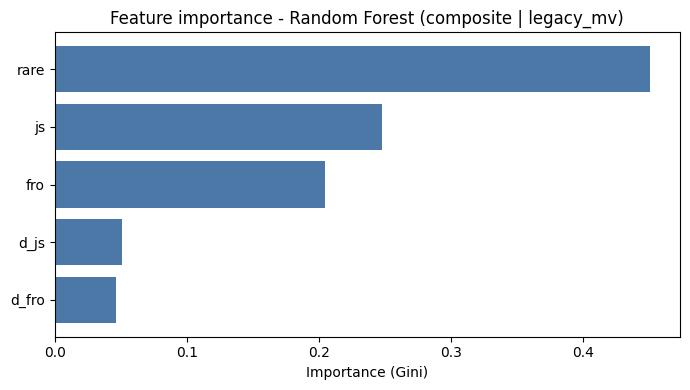

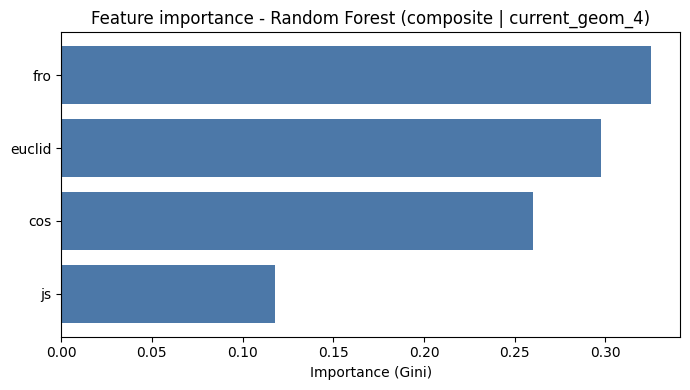

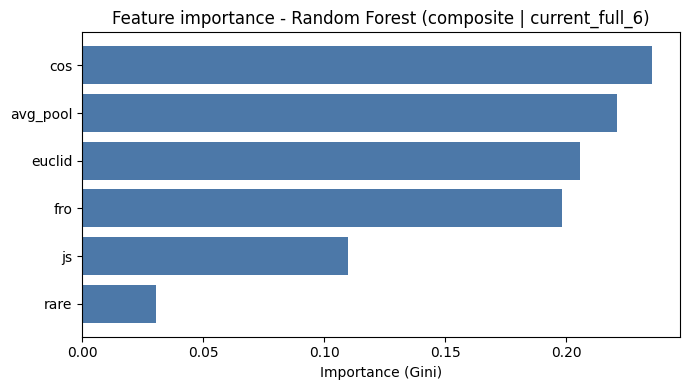

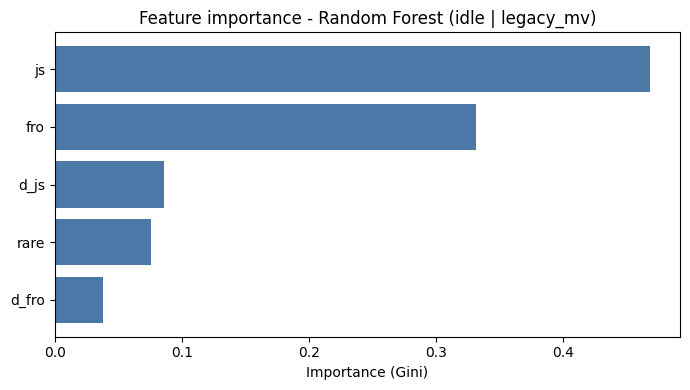

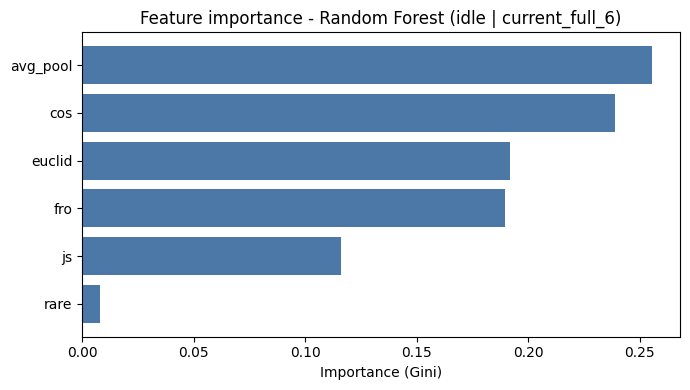

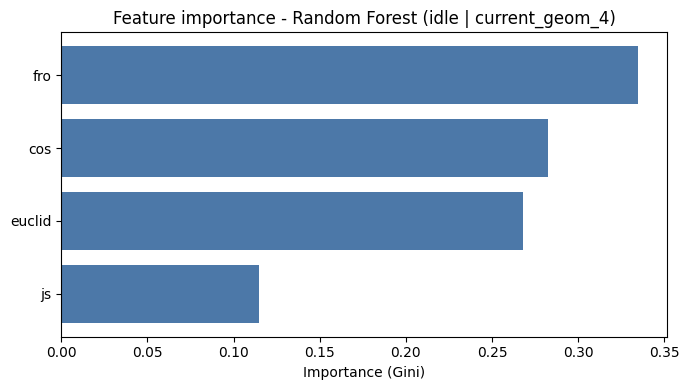

In [26]:
# --- Feature importance (Random Forest) ---
TOP_K = 10
TOP_RF_PLOTS = 6

for _, row in result_random_forest.head(TOP_RF_PLOTS).iterrows():
    rep_name = row['representacao']
    subset_name = row['subset_features']
    model = rf_models[(rep_name, subset_name)]
    names = feature_set_names_by_rep[rep_name][subset_name]
    importances = model.feature_importances_
    order = np.argsort(importances)[::-1]

    top_idx = order[:min(TOP_K, len(names))]
    top_names = [names[i] for i in top_idx]
    top_vals = importances[top_idx]

    plt.figure(figsize=(7, 4))
    plt.barh(top_names[::-1], top_vals[::-1], color='#4C78A8')
    plt.title(f'Feature importance - Random Forest ({rep_name} | {subset_name})')
    plt.xlabel('Importance (Gini)')
    plt.tight_layout()
    plt.show()


### 9.5 XGBoost (supervised)

If `xgboost` is available, we use `XGBClassifier`; otherwise, we fall back to `HistGradientBoosting` and record that choice.

In [27]:
xgb_rows = []
xgb_models = {}

for rep_name, subset_catalog in feature_sets_by_rep.items():
    for subset_name, subset_obj in subset_catalog.items():
        X_rep = subset_obj['X']
        X_train_sup = X_rep[idx_pretest]
        y_train_sup = y_windows[idx_pretest]
        X_test_sup = X_rep[idx_test]
        y_test_sup = y_windows[idx_test]

        if HAS_XGBOOST:
            n_pos = max(int(y_train_sup.sum()), 1)
            n_neg = max(int(len(y_train_sup) - y_train_sup.sum()), 1)
            spw = n_neg / n_pos

            model_xgboost = XGBClassifier(
                n_estimators=400,
                max_depth=6,
                learning_rate=0.05,
                subsample=0.9,
                colsample_bytree=0.8,
                objective='binary:logistic',
                eval_metric='logloss',
                random_state=SEED,
                scale_pos_weight=spw,
            )
            model_xgboost.fit(X_train_sup, y_train_sup)

            score_xgboost = model_xgboost.predict_proba(X_test_sup)[:, 1]
            flags_xgboost = score_xgboost >= 0.5

            metrics_xgboost = binary_metrics(y_test_sup, flags_xgboost, score_xgboost)
            row = {
                'modelo': 'XGBoost',
                'representacao': rep_name,
                'protocolo_features': subset_obj['protocolo_features'],
                'subset_features': subset_name,
                'variante': 'xgb',
                'features_usadas': ', '.join(subset_obj['feature_names']),
                'n_features': int(subset_obj['n_features']),
                'thr': 0.5,
                **metrics_xgboost,
            }
        else:
            model_xgboost = HistGradientBoostingClassifier(
                learning_rate=0.05,
                max_depth=8,
                random_state=SEED,
            )
            model_xgboost.fit(X_train_sup, y_train_sup)

            score_xgboost = model_xgboost.predict_proba(X_test_sup)[:, 1]
            flags_xgboost = score_xgboost >= 0.5

            metrics_xgboost = binary_metrics(y_test_sup, flags_xgboost, score_xgboost)
            row = {
                'modelo': 'XGBoost (fallback HGB)',
                'representacao': rep_name,
                'protocolo_features': subset_obj['protocolo_features'],
                'subset_features': subset_name,
                'variante': 'hgb',
                'features_usadas': ', '.join(subset_obj['feature_names']),
                'n_features': int(subset_obj['n_features']),
                'thr': 0.5,
                **metrics_xgboost,
            }

        xgb_rows.append(row)
        xgb_models[(rep_name, subset_name)] = model_xgboost

result_xgboost = pd.DataFrame(xgb_rows).sort_values(
    ['objective_score', 'f1', 'mcc'],
    ascending=False,
).reset_index(drop=True)

result_xgboost


,modelo,representacao,protocolo_features,subset_features,variante,features_usadas,n_features,thr,precision,recall,...,false_alarm_rate,accuracy,balanced_accuracy,mcc,avg_precision,objective_score,tp,fp,fn,tn
0,XGBoost,composite,legacy,legacy_mv,xgb,"js, fro, d_js, d_fro, rare",5,0.5,0.599805,0.868734,...,0.036871,0.957484,0.915932,0.701289,0.885892,0.925724,4315,2879,652,75205
1,XGBoost,idle,legacy,legacy_univar_js,xgb,js,1,0.5,0.695506,0.582645,...,0.016226,0.959784,0.783210,0.615682,0.649556,0.824216,2894,1267,2073,76817
2,XGBoost,idle,legacy,legacy_mv,xgb,"js, fro, d_js, d_fro, rare",5,0.5,0.572713,0.654117,...,0.031043,0.950127,0.811537,0.585669,0.718572,0.802733,3249,2424,1718,75660
3,XGBoost,idle,current,current_full_6,xgb,"js, fro, rare, cos, euclid, avg_pool",6,0.5,0.573671,0.588685,...,0.027829,0.949236,0.780428,0.554119,0.635419,0.766448,2924,2173,2043,75911
4,XGBoost,idle,current,current_geom_4,xgb,"js, fro, cos, euclid",4,0.5,0.554649,0.588484,...,0.030057,0.947129,0.779213,0.543190,0.634119,0.755349,2923,2347,2044,75737
5,XGBoost,idle,current,current_univar_cos,xgb,cos,1,0.5,0.611555,0.524260,...,0.021182,0.951632,0.751539,0.540900,0.582883,0.745024,2604,1654,2363,76430
6,XGBoost,composite,current,current_full_6,xgb,"js, fro, rare, cos, euclid, avg_pool",6,0.5,0.410277,0.839138,...,0.076725,0.918243,0.881207,0.551764,0.812070,0.744552,4168,5991,799,72093
7,XGBoost,idle,current,current_pair_cos_euclid,xgb,"cos, euclid",2,0.5,0.527718,0.590296,...,0.033605,0.943902,0.778346,0.528353,0.638849,0.740080,2932,2624,2035,75460
8,XGBoost,composite,current,current_geom_4,xgb,"js, fro, cos, euclid",4,0.5,0.393402,0.835514,...,0.081950,0.913114,0.876782,0.536621,0.809245,0.725445,4150,6399,817,71685
9,XGBoost,idle,current,current_pair_rare_avg_pool,xgb,"rare, avg_pool",2,0.5,0.478685,0.583249,...,0.040405,0.937087,0.771422,0.495235,0.611398,0.704533,2897,3155,2070,74929


### 9.6 AutoML (LazyPredict)

In [28]:
# from lazypredict.Supervised import LazyClassifier

# automl_rows = []
# automl_leaderboard_by_config = {}
# automl_models = {}

# split_inner = int(0.80 * len(idx_pretest))
# idx_train_inner = idx_pretest[:split_inner]
# idx_val_inner = idx_pretest[split_inner:]

# for rep_name, subset_catalog in feature_sets_by_rep.items():
#     for subset_name, subset_obj in subset_catalog.items():
#         X_rep = subset_obj['X']
#         X_train_inner = X_rep[idx_train_inner]
#         y_train_inner = y_windows[idx_train_inner]
#         X_val_inner = X_rep[idx_val_inner]
#         y_val_inner = y_windows[idx_val_inner]

#         X_train_sup = X_rep[idx_pretest]
#         y_train_sup = y_windows[idx_pretest]
#         X_test_sup = X_rep[idx_test]
#         y_test_sup = y_windows[idx_test]

#         lazy_clf = LazyClassifier(
#             verbose=0,
#             ignore_warnings=True,
#             custom_metric=None,
#             predictions=True,
#         )

#         models_df, predictions_df = lazy_clf.fit(
#             X_train_inner,
#             X_val_inner,
#             y_train_inner,
#             y_val_inner,
#         )

#         automl_leaderboard = (
#             models_df.reset_index()
#             .rename(columns={'index': 'candidate'})
#             .copy()
#         )

#         rename_map = {
#             'Balanced Accuracy': 'balanced_accuracy',
#             'ROC AUC': 'roc_auc',
#             'F1 Score': 'f1_lazy',
#             'Accuracy': 'accuracy',
#             'Time Taken': 'time_taken',
#         }
#         automl_leaderboard = automl_leaderboard.rename(columns=rename_map)

#         sort_cols = [c for c in ['ROC AUC', 'Balanced Accuracy', 'F1 Score', 'Accuracy'] if c in models_df.columns]
#         if not sort_cols:
#             raise ValueError('O leaderboard do LazyPredict não trouxe colunas esperadas para seleção do melhor modelo.')

#         best_candidate_name = (
#             models_df.sort_values(sort_cols, ascending=False)
#             .reset_index()
#             .iloc[0]['Model']
#         )

#         fitted_models = lazy_clf.provide_models(
#             X_train_inner,
#             X_val_inner,
#             y_train_inner,
#             y_val_inner,
#         )

#         best_model = fitted_models[best_candidate_name]
#         best_model.fit(X_train_sup, y_train_sup)

#         if hasattr(best_model, 'predict_proba'):
#             score_test = best_model.predict_proba(X_test_sup)[:, 1]
#         elif hasattr(best_model, 'decision_function'):
#             score_test = best_model.decision_function(X_test_sup)
#         else:
#             score_test = best_model.predict(X_test_sup)

#         flags_test = score_test >= 0.5
#         m_test = binary_metrics(y_test_sup, flags_test, score_test)

#         automl_rows.append({
#             'modelo': 'LazyPredict',
#             'representacao': rep_name,
#             'protocolo_features': subset_obj['protocolo_features'],
#             'subset_features': subset_name,
#             'variante': str(best_candidate_name),
#             'features_usadas': ', '.join(subset_obj['feature_names']),
#             'n_features': int(subset_obj['n_features']),
#             'thr': 0.5,
#             **m_test,
#         })

#         automl_leaderboard_by_config[(rep_name, subset_name)] = automl_leaderboard
#         automl_models[(rep_name, subset_name)] = best_model

# result_automl = pd.DataFrame(automl_rows).sort_values(
#     ['objective_score', 'f1', 'mcc'],
#     ascending=False,
# ).reset_index(drop=True)

# sample_key = next(iter(automl_leaderboard_by_config))
# print('LazyPredict leaderboard sample:', sample_key)
# display(automl_leaderboard_by_config[sample_key].head(10))

# print('LazyPredict results by representation and subset:')
# result_automl.head(12)


### 9.7 Artificial Neural Network (MLP)

A tabular ANN with `MLPClassifier` (two hidden layers), trained on the pre-test segment.

In [29]:
mlp_rows = []
mlp_models = {}

for rep_name, subset_catalog in feature_sets_by_rep.items():
    for subset_name, subset_obj in subset_catalog.items():
        X_rep = subset_obj['X']
        X_train_sup = X_rep[idx_pretest]
        y_train_sup = y_windows[idx_pretest]
        X_test_sup = X_rep[idx_test]
        y_test_sup = y_windows[idx_test]

        model_mlp = Pipeline([
            ('scaler', StandardScaler()),
            ('mlp', MLPClassifier(
                hidden_layer_sizes=(64, 32),
                activation='relu',
                alpha=1e-4,
                learning_rate_init=1e-3,
                max_iter=300,
                early_stopping=True,
                random_state=SEED,
            ))
        ])

        model_mlp.fit(X_train_sup, y_train_sup)
        score_mlp = model_mlp.predict_proba(X_test_sup)[:, 1]
        flags_mlp = score_mlp >= 0.5

        metrics_mlp = binary_metrics(y_test_sup, flags_mlp, score_mlp)
        mlp_rows.append({
            'modelo': 'ANN (MLP)',
            'representacao': rep_name,
            'protocolo_features': subset_obj['protocolo_features'],
            'subset_features': subset_name,
            'variante': 'mlp',
            'features_usadas': ', '.join(subset_obj['feature_names']),
            'n_features': int(subset_obj['n_features']),
            'thr': 0.5,
            **metrics_mlp,
        })

        mlp_models[(rep_name, subset_name)] = model_mlp

result_mlp = pd.DataFrame(mlp_rows).sort_values(
    ['objective_score', 'f1', 'mcc'],
    ascending=False,
).reset_index(drop=True)

result_mlp


,modelo,representacao,protocolo_features,subset_features,variante,features_usadas,n_features,thr,precision,recall,...,false_alarm_rate,accuracy,balanced_accuracy,mcc,avg_precision,objective_score,tp,fp,fn,tn
0,ANN (MLP),composite,legacy,legacy_mv,mlp,"js, fro, d_js, d_fro, rare",5,0.5,0.851656,0.843769,...,0.009349,0.981867,0.917210,0.838064,0.907156,1.073725,4191,730,776,77354
1,ANN (MLP),len,legacy,legacy_mv,mlp,"js, fro, d_js, d_fro, rare",5,0.5,0.992100,0.733239,...,0.000371,0.983697,0.866434,0.845485,0.782240,1.059729,3642,29,1325,78055
2,ANN (MLP),len,legacy,legacy_univar_fro,mlp,fro,1,0.5,0.998579,0.707469,...,0.000064,0.982445,0.853703,0.832752,0.768535,1.041591,3514,5,1453,78079
3,ANN (MLP),composite,legacy,legacy_univar_fro,mlp,fro,1,0.5,0.999710,0.693376,...,0.000013,0.981650,0.846682,0.824559,0.775412,1.030496,3444,1,1523,78083
4,ANN (MLP),composite,current,current_geom_4,mlp,"js, fro, cos, euclid",4,0.5,0.995442,0.659553,...,0.000192,0.979458,0.829680,0.801484,0.811242,1.000765,3276,15,1691,78069
5,ANN (MLP),composite,legacy,legacy_univar_js,mlp,js,1,0.5,0.913629,0.696396,...,0.004188,0.977905,0.846104,0.786926,0.794256,1.000418,3459,327,1508,77757
6,ANN (MLP),len,legacy,legacy_univar_js,mlp,js,1,0.5,0.995244,0.631971,...,0.000192,0.977809,0.815889,0.783785,0.750342,0.976963,3139,15,1828,78069
7,ANN (MLP),composite,current,current_full_6,mlp,"js, fro, rare, cos, euclid, avg_pool",6,0.5,0.987654,0.628146,...,0.000499,0.977291,0.813823,0.778066,0.779664,0.971186,3120,39,1847,78045
8,ANN (MLP),idle,legacy,legacy_univar_js,mlp,js,1,0.5,0.994014,0.568351,...,0.000218,0.973980,0.784067,0.741314,0.652048,0.919138,2823,17,2144,78067
9,ANN (MLP),idle,legacy,legacy_mv,mlp,"js, fro, d_js, d_fro, rare",5,0.5,0.965152,0.568754,...,0.001306,0.972980,0.783724,0.729728,0.701737,0.911207,2825,102,2142,77982


### 9.8 Autoencoder (arquitetura mais pesada, opcional com PyTorch)

- If `torch` is available: we train a simple autoencoder on `baseline` (normal),
  we calibrate the threshold on `tune` and evaluate on `test`.
- If it is not available: we mark it as `skip` so the notebook does not break.

In [30]:
# autoencoder_rows = []
# ae_models = {}

# if HAS_TORCH:
#     for rep_name, subset_catalog in feature_sets_by_rep.items():
#         for subset_name, subset_obj in subset_catalog.items():
#             X_rep = subset_obj['X']
#             scaler_ae = StandardScaler().fit(X_rep[idx_baseline])
#             X_train_ae = scaler_ae.transform(X_rep[idx_baseline]).astype(np.float32)
#             X_all_ae = scaler_ae.transform(X_rep).astype(np.float32)

#             class AE(nn.Module):
#                 def __init__(self, in_dim):
#                     super().__init__()
#                     self.enc = nn.Sequential(
#                         nn.Linear(in_dim, 64),
#                         nn.ReLU(),
#                         nn.Linear(64, 16),
#                         nn.ReLU(),
#                     )
#                     self.dec = nn.Sequential(
#                         nn.Linear(16, 64),
#                         nn.ReLU(),
#                         nn.Linear(64, in_dim),
#                     )

#                 def forward(self, x):
#                     z = self.enc(x)
#                     return self.dec(z)

#             torch.manual_seed(SEED)
#             ae_model = AE(X_train_ae.shape[1])
#             optimizer = optim.Adam(ae_model.parameters(), lr=1e-3)
#             criterion = nn.MSELoss()

#             Xtr = torch.from_numpy(X_train_ae)

#             ae_model.train()
#             for epoch in range(25):
#                 optimizer.zero_grad()
#                 out = ae_model(Xtr)
#                 loss = criterion(out, Xtr)
#                 loss.backward()
#                 optimizer.step()

#             ae_model.eval()
#             with torch.no_grad():
#                 Xall_t = torch.from_numpy(X_all_ae)
#                 rec = ae_model(Xall_t).numpy()

#             score_autoencoder = np.mean((rec - X_all_ae) ** 2, axis=1)
#             thr_autoencoder, _ = tune_threshold_from_scores(score_autoencoder, y_windows, idx_tune)
#             flags_autoencoder = score_autoencoder > thr_autoencoder

#             metrics_autoencoder = binary_metrics(
#                 y_windows[idx_test], flags_autoencoder[idx_test], score_autoencoder[idx_test]
#             )

#             autoencoder_rows.append({
#                 'modelo': 'Autoencoder (PyTorch)',
#                 'representacao': rep_name,
#                 'protocolo_features': subset_obj['protocolo_features'],
#                 'subset_features': subset_name,
#                 'variante': 'ae',
#                 'features_usadas': ', '.join(subset_obj['feature_names']),
#                 'n_features': int(subset_obj['n_features']),
#                 'thr': float(thr_autoencoder),
#                 **metrics_autoencoder,
#             })

#             ae_models[(rep_name, subset_name)] = ae_model
# else:
#     for rep_name, subset_catalog in feature_sets_by_rep.items():
#         for subset_name, subset_obj in subset_catalog.items():
#             autoencoder_rows.append({
#                 'modelo': 'Autoencoder (PyTorch)',
#                 'representacao': rep_name,
#                 'protocolo_features': subset_obj['protocolo_features'],
#                 'subset_features': subset_name,
#                 'variante': 'indisponivel_sem_torch',
#                 'features_usadas': ', '.join(subset_obj['feature_names']),
#                 'n_features': int(subset_obj['n_features']),
#                 'thr': np.nan,
#                 'precision': np.nan,
#                 'recall': np.nan,
#                 'f1': np.nan,
#                 'false_alarm_rate': np.nan,
#                 'accuracy': np.nan,
#                 'balanced_accuracy': np.nan,
#                 'mcc': np.nan,
#                 'avg_precision': np.nan,
#                 'objective_score': np.nan,
#                 'tp': np.nan,
#                 'fp': np.nan,
#                 'fn': np.nan,
#                 'tn': np.nan,
#             })

# result_autoencoder = pd.DataFrame(autoencoder_rows).sort_values(
#     ['objective_score', 'f1', 'mcc'],
#     ascending=False,
#     na_position='last'
# ).reset_index(drop=True)

# result_autoencoder


### 9.9 Kolmogorov-Arnold Network (KAN)

Implementation with `pykan`, in classification mode (`output_dim=2` + `CrossEntropyLoss`).

- Supervised training on `pre-test` (`baseline + tune`).
- Evaluation on `test` using the anomalous-class probability.
- To control cost, we limit the number of training samples with `KAN_MAX_TRAIN_SAMPLES`.


In [31]:
kan_rows = []
kan_models = {}

if HAS_KAN and HAS_TORCH:
    device_kan = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    for rep_name, subset_catalog in feature_sets_by_rep.items():
        for subset_name, subset_obj in subset_catalog.items():
            X_rep = subset_obj['X']
            X_train_sup = X_rep[idx_pretest].astype(np.float32)
            y_train_sup = y_windows[idx_pretest].astype(np.int64)
            X_test_sup = X_rep[idx_test].astype(np.float32)
            y_test_sup = y_windows[idx_test].astype(np.int64)

            if len(X_train_sup) > KAN_MAX_TRAIN_SAMPLES:
                rng = np.random.default_rng(SEED)
                sel = rng.choice(len(X_train_sup), size=KAN_MAX_TRAIN_SAMPLES, replace=False)
                X_train_k = X_train_sup[sel]
                y_train_k = y_train_sup[sel]
            else:
                X_train_k = X_train_sup
                y_train_k = y_train_sup

            dtype = torch.get_default_dtype()
            dataset_kan = {
                'train_input': torch.from_numpy(X_train_k).type(dtype).to(device_kan),
                'test_input': torch.from_numpy(X_test_sup).type(dtype).to(device_kan),
                'train_label': torch.from_numpy(y_train_k).type(torch.long).to(device_kan),
                'test_label': torch.from_numpy(y_test_sup).type(torch.long).to(device_kan),
            }

            in_dim = int(X_train_k.shape[1])
            model_kan = KAN(
                width=[in_dim, KAN_WIDTH_HIDDEN, 2],
                grid=KAN_GRID,
                k=KAN_K,
                seed=SEED,
                device=device_kan,
            )

            def kan_train_acc():
                with torch.no_grad():
                    logits = model_kan(dataset_kan['train_input'])
                    pred = torch.argmax(logits, dim=1)
                    return torch.mean((pred == dataset_kan['train_label']).type(dtype))

            def kan_test_acc():
                with torch.no_grad():
                    logits = model_kan(dataset_kan['test_input'])
                    pred = torch.argmax(logits, dim=1)
                    return torch.mean((pred == dataset_kan['test_label']).type(dtype))

            try:
                _ = model_kan.fit(
                    dataset_kan,
                    opt=KAN_OPT,
                    steps=KAN_STEPS,
                    metrics=(kan_train_acc, kan_test_acc),
                    loss_fn=torch.nn.CrossEntropyLoss(),
                )

                with torch.no_grad():
                    logits_test = model_kan(dataset_kan['test_input'])
                    probs_test = torch.softmax(logits_test, dim=1)[:, 1].detach().cpu().numpy()

                flags_kan = probs_test >= 0.5
                metrics_kan = binary_metrics(y_test_sup, flags_kan, probs_test)

                kan_rows.append({
                    'modelo': 'KAN (pykan)',
                    'representacao': rep_name,
                    'protocolo_features': subset_obj['protocolo_features'],
                    'subset_features': subset_name,
                    'variante': f'width=[{in_dim},{KAN_WIDTH_HIDDEN},2],grid={KAN_GRID},k={KAN_K},steps={KAN_STEPS}',
                    'features_usadas': ', '.join(subset_obj['feature_names']),
                    'n_features': int(subset_obj['n_features']),
                    'thr': 0.5,
                    **metrics_kan,
                })

                kan_models[(rep_name, subset_name)] = model_kan

            except Exception as e:
                kan_rows.append({
                    'modelo': 'KAN (pykan)',
                    'representacao': rep_name,
                    'protocolo_features': subset_obj['protocolo_features'],
                    'subset_features': subset_name,
                    'variante': f'falha_treino:{type(e).__name__}',
                    'features_usadas': ', '.join(subset_obj['feature_names']),
                    'n_features': int(subset_obj['n_features']),
                    'thr': np.nan,
                    'precision': np.nan,
                    'recall': np.nan,
                    'f1': np.nan,
                    'false_alarm_rate': np.nan,
                    'accuracy': np.nan,
                    'balanced_accuracy': np.nan,
                    'mcc': np.nan,
                    'avg_precision': np.nan,
                    'objective_score': np.nan,
                    'tp': np.nan,
                    'fp': np.nan,
                    'fn': np.nan,
                    'tn': np.nan,
                })
else:
    for rep_name, subset_catalog in feature_sets_by_rep.items():
        for subset_name, subset_obj in subset_catalog.items():
            kan_rows.append({
                'modelo': 'KAN (pykan)',
                'representacao': rep_name,
                'protocolo_features': subset_obj['protocolo_features'],
                'subset_features': subset_name,
                'variante': 'indisponivel_sem_kan_ou_torch',
                'features_usadas': ', '.join(subset_obj['feature_names']),
                'n_features': int(subset_obj['n_features']),
                'thr': np.nan,
                'precision': np.nan,
                'recall': np.nan,
                'f1': np.nan,
                'false_alarm_rate': np.nan,
                'accuracy': np.nan,
                'balanced_accuracy': np.nan,
                'mcc': np.nan,
                'avg_precision': np.nan,
                'objective_score': np.nan,
                'tp': np.nan,
                'fp': np.nan,
                'fn': np.nan,
                'tn': np.nan,
            })

result_kan = pd.DataFrame(kan_rows).sort_values(
    ['objective_score', 'f1', 'mcc'],
    ascending=False,
    na_position='last'
).reset_index(drop=True)

result_kan


checkpoint directory created: ./model
saving model version 0.0


| train_loss: 3.88e-01 | test_loss: 3.24e-01 | reg: 4.75e+01 | : 100%|█| 25/25 [00:10<00:00,  2.49it


saving model version 0.1
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 3.90e-01 | test_loss: 3.07e-01 | reg: 4.57e+01 | : 100%|█| 25/25 [00:09<00:00,  2.63it


saving model version 0.1
checkpoint directory created: ./model
saving model version 0.0


...

| train_loss: 3.65e-01 | test_loss: 3.40e-01 | reg: 4.15e+02 | : 100%|█| 25/25 [00:11<00:00,  2.22it


saving model version 0.1
checkpoint directory created: ./model
saving model version 0.0


| train_loss: 3.54e-01 | test_loss: 3.44e-01 | reg: 8.31e+01 | : 100%|█| 25/25 [00:12<00:00,  2.02it


saving model version 0.1


,modelo,representacao,protocolo_features,subset_features,variante,features_usadas,n_features,thr,precision,recall,...,false_alarm_rate,accuracy,balanced_accuracy,mcc,avg_precision,objective_score,tp,fp,fn,tn
0,KAN (pykan),len,legacy,legacy_mv,"width=[5,8,2],grid=3,k=3,steps=25","js, fro, d_js, d_fro, rare",5,0.5,0.995833,0.721764,...,0.000192,0.983179,0.860786,0.840246,0.794268,1.052062,3585.0,15.0,1382.0,78069.0
1,KAN (pykan),len,legacy,legacy_univar_fro,"width=[1,8,2],grid=3,k=3,steps=25",fro,1,0.5,1.000000,0.703644,...,0.000000,0.982276,0.851822,0.831038,0.768092,1.039001,3495.0,0.0,1472.0,78084.0
2,KAN (pykan),composite,legacy,legacy_univar_fro,"width=[1,8,2],grid=3,k=3,steps=25",fro,1,0.5,1.000000,0.690960,...,0.000000,0.981517,0.845480,0.823188,0.763188,1.028610,3432.0,0.0,1535.0,78084.0
3,KAN (pykan),composite,legacy,legacy_univar_js,"width=[1,8,2],grid=3,k=3,steps=25",js,1,0.5,0.932323,0.693376,...,0.003202,0.978652,0.845087,0.793864,0.793493,1.005440,3444.0,250.0,1523.0,77834.0
4,KAN (pykan),composite,legacy,legacy_mv,"width=[5,8,2],grid=3,k=3,steps=25","js, fro, d_js, d_fro, rare",5,0.5,0.887806,0.715321,...,0.005750,0.977568,0.854785,0.785665,0.793306,1.003968,3553.0,449.0,1414.0,77635.0
5,KAN (pykan),len,legacy,legacy_univar_js,"width=[1,8,2],grid=3,k=3,steps=25",js,1,0.5,0.922373,0.669821,...,0.003586,0.976882,0.833117,0.775090,0.753452,0.983091,3327.0,280.0,1640.0,77804.0
6,KAN (pykan),idle,legacy,legacy_univar_js,"width=[1,8,2],grid=3,k=3,steps=25",js,1,0.5,0.997518,0.566338,...,0.000090,0.973980,0.783124,0.741377,0.643289,0.918236,2813.0,7.0,2154.0,78077.0
7,KAN (pykan),len,current,current_geom_4,"width=[4,8,2],grid=3,k=3,steps=25","js, fro, cos, euclid",4,0.5,0.998201,0.558687,...,0.000064,0.973546,0.779312,0.736454,0.686872,0.911212,2775.0,5.0,2192.0,78079.0
8,KAN (pykan),composite,current,current_full_6,"width=[6,8,2],grid=3,k=3,steps=25","js, fro, rare, cos, euclid, avg_pool",6,0.5,0.955672,0.551238,...,0.001626,0.971632,0.774806,0.714122,0.707697,0.892315,2738.0,127.0,2229.0,77957.0
9,KAN (pykan),idle,current,current_full_6,"width=[6,8,2],grid=3,k=3,steps=25","js, fro, rare, cos, euclid, avg_pool",6,0.5,0.978506,0.540769,...,0.000756,0.971825,0.770007,0.716288,0.635952,0.888814,2686.0,59.0,2281.0,78025.0


## 10) Consolidation of global results

In this section we aggregate one row per **algorithm x representation** (`len`, `idle`, `composite`).

That is, each model family contributes three separate results for a fair comparison across configurations.


In [32]:
resultados_lista = [
    result_teda,
    result_iforest,
    result_ocsvm,
    result_random_forest,
    result_xgboost,
    # result_automl,
    result_mlp,
    # result_autoencoder,
    result_kan,
]

results_globais = pd.concat(resultados_lista, ignore_index=True)
results_globais = results_globais.sort_values(
    ['objective_score', 'f1', 'mcc'],
    ascending=False,
    na_position='last'
).reset_index(drop=True)

cols_final = [
    'modelo', 'representacao', 'protocolo_features', 'subset_features', 'variante', 'features_usadas', 'n_features', 'thr',
    'f1', 'precision', 'recall',
    'false_alarm_rate', 'accuracy', 'balanced_accuracy', 'mcc',
    'avg_precision', 'objective_score',
    'tp', 'fp', 'fn', 'tn',
]
cols_final = [c for c in cols_final if c in results_globais.columns]
results_globais = results_globais[cols_final]

import os
os.makedirs(OUT_DIR, exist_ok=True)
results_globais.to_csv(OUT_RESULTS_CSV, index=False)

print('Resultados globais salvos em:', OUT_RESULTS_CSV)
print('Total rows (algorithms x representations x subsets):', len(results_globais))
results_globais


Resultados globais salvos em: ../outputs/article_case_study_final/resultados_globais_modelos.csv
Total rows (algorithms x representations x subsets): 294


,modelo,representacao,protocolo_features,subset_features,variante,features_usadas,n_features,thr,f1,precision,...,false_alarm_rate,accuracy,balanced_accuracy,mcc,avg_precision,objective_score,tp,fp,fn,tn
0,ANN (MLP),composite,legacy,legacy_mv,mlp,"js, fro, d_js, d_fro, rare",5,0.5,0.847694,0.851656,...,0.009349,0.981867,0.917210,0.838064,0.907156,1.073725,4191.0,730.0,776.0,77354.0
1,ANN (MLP),len,legacy,legacy_mv,mlp,"js, fro, d_js, d_fro, rare",5,0.5,0.843251,0.992100,...,0.000371,0.983697,0.866434,0.845485,0.782240,1.059729,3642.0,29.0,1325.0,78055.0
2,KAN (pykan),len,legacy,legacy_mv,"width=[5,8,2],grid=3,k=3,steps=25","js, fro, d_js, d_fro, rare",5,0.5,0.836932,0.995833,...,0.000192,0.983179,0.860786,0.840246,0.794268,1.052062,3585.0,15.0,1382.0,78069.0
3,Random Forest,composite,legacy,legacy_mv,rf,"js, fro, d_js, d_fro, rare",5,0.5,0.827523,0.833095,...,0.010476,0.979507,0.905775,0.816651,0.904859,1.050300,4083.0,818.0,884.0,77266.0
4,ANN (MLP),len,legacy,legacy_univar_fro,mlp,fro,1,0.5,0.828188,0.998579,...,0.000064,0.982445,0.853703,0.832752,0.768535,1.041591,3514.0,5.0,1453.0,78079.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
289,Random Forest,composite,current,current_univar_rare,rf,rare,1,0.5,0.146837,0.079656,...,0.689091,0.348388,0.624248,0.129078,0.176624,0.061717,4657.0,53807.0,310.0,24277.0
290,XGBoost,composite,current,current_univar_rare,xgb,rare,1,0.5,0.148036,0.080174,...,0.703499,0.336420,0.630232,0.137419,0.174575,0.059369,4788.0,54932.0,179.0,23152.0
291,Random Forest,len,current,current_univar_rare,rf,rare,1,0.5,0.127580,0.068579,...,0.789150,0.252869,0.562139,0.073210,0.128525,-0.008088,4537.0,61620.0,430.0,16464.0
292,XGBoost,len,current,current_univar_rare,xgb,rare,1,0.5,0.123966,0.066588,...,0.799229,0.242369,0.548543,0.058111,0.084402,-0.018628,4452.0,62407.0,515.0,15677.0


In [33]:
# --- Slide 6: top resultados por representação ---
TOP_K = 10
cols_show = ['modelo', 'representacao', 'features_usadas', 'f1', 'far', 'mcc', 'bacc', 'objective_score', 'accuracy']
cols_show = [c for c in cols_show if c in results_globais.columns]
for rep in ['len', 'idle', 'composite']:
    print(f'\nTop {TOP_K} - representation: {rep}')
    rep_df = results_globais[results_globais['representacao'] == rep].copy()
    rep_df = rep_df.sort_values(['objective_score', 'f1', 'mcc'], ascending=False, na_position='last')
    display(rep_df[cols_show].head(TOP_K))



Top 10 - representation: len


,modelo,representacao,features_usadas,f1,mcc,objective_score,accuracy
1,ANN (MLP),len,"js, fro, d_js, d_fro, rare",0.843251,0.845485,1.059729,0.983697
2,KAN (pykan),len,"js, fro, d_js, d_fro, rare",0.836932,0.840246,1.052062,0.983179
4,ANN (MLP),len,fro,0.828188,0.832752,1.041591,0.982445
5,KAN (pykan),len,fro,0.826046,0.831038,1.039001,0.982276
12,KAN (pykan),len,js,0.776067,0.775090,0.983091,0.976882
13,ANN (MLP),len,js,0.773058,0.783785,0.976963,0.977809
16,TEDA,len,"js, fro, d_js, d_fro, rare",0.748394,0.763567,0.948137,0.975955
17,TEDA,len,js,0.738219,0.754994,0.936352,0.975184
24,TEDA,len,fro,0.719515,0.739374,0.914754,0.973799
25,KAN (pykan),len,"js, fro, cos, euclid",0.716406,0.736454,0.911212,0.973546



Top 10 - representation: idle


,modelo,representacao,features_usadas,f1,mcc,objective_score,accuracy
22,ANN (MLP),idle,js,0.723197,0.741314,0.919138,0.973980
23,KAN (pykan),idle,js,0.722486,0.741377,0.918236,0.973980
26,ANN (MLP),idle,"js, fro, d_js, d_fro, rare",0.715733,0.729728,0.911207,0.972980
28,Random Forest,idle,"js, fro, d_js, d_fro, rare",0.704534,0.710022,0.899720,0.971126
29,ANN (MLP),idle,"js, fro, cos, euclid",0.705761,0.723580,0.899422,0.972451
30,ANN (MLP),idle,"js, fro, rare, cos, euclid, avg_pool",0.703912,0.719674,0.897574,0.972114
31,ANN (MLP),idle,"cos, euclid",0.700451,0.718665,0.893364,0.972029
32,Random Forest,idle,"js, fro, rare, cos, euclid, avg_pool",0.698907,0.709015,0.892630,0.971138
34,Random Forest,idle,"js, fro, cos, euclid",0.698149,0.708900,0.891680,0.971138
35,KAN (pykan),idle,"js, fro, rare, cos, euclid, avg_pool",0.696577,0.716288,0.888814,0.971825



Top 10 - representation: composite


,modelo,representacao,features_usadas,f1,mcc,objective_score,accuracy
0,ANN (MLP),composite,"js, fro, d_js, d_fro, rare",0.847694,0.838064,1.073725,0.981867
3,Random Forest,composite,"js, fro, d_js, d_fro, rare",0.827523,0.816651,1.050300,0.979507
6,ANN (MLP),composite,fro,0.818830,0.824559,1.030496,0.981650
7,KAN (pykan),composite,fro,0.817240,0.823188,1.028610,0.981517
8,KAN (pykan),composite,js,0.795289,0.793864,1.005440,0.978652
9,KAN (pykan),composite,"js, fro, d_js, d_fro, rare",0.792285,0.785665,1.003968,0.977568
10,ANN (MLP),composite,"js, fro, cos, euclid",0.793412,0.801484,1.000765,0.979458
11,ANN (MLP),composite,js,0.790358,0.786926,1.000418,0.977905
14,ANN (MLP),composite,"js, fro, rare, cos, euclid, avg_pool",0.767905,0.778066,0.971186,0.977291
15,TEDA,composite,"js, fro, d_js, d_fro, rare",0.757163,0.771002,0.958315,0.976629


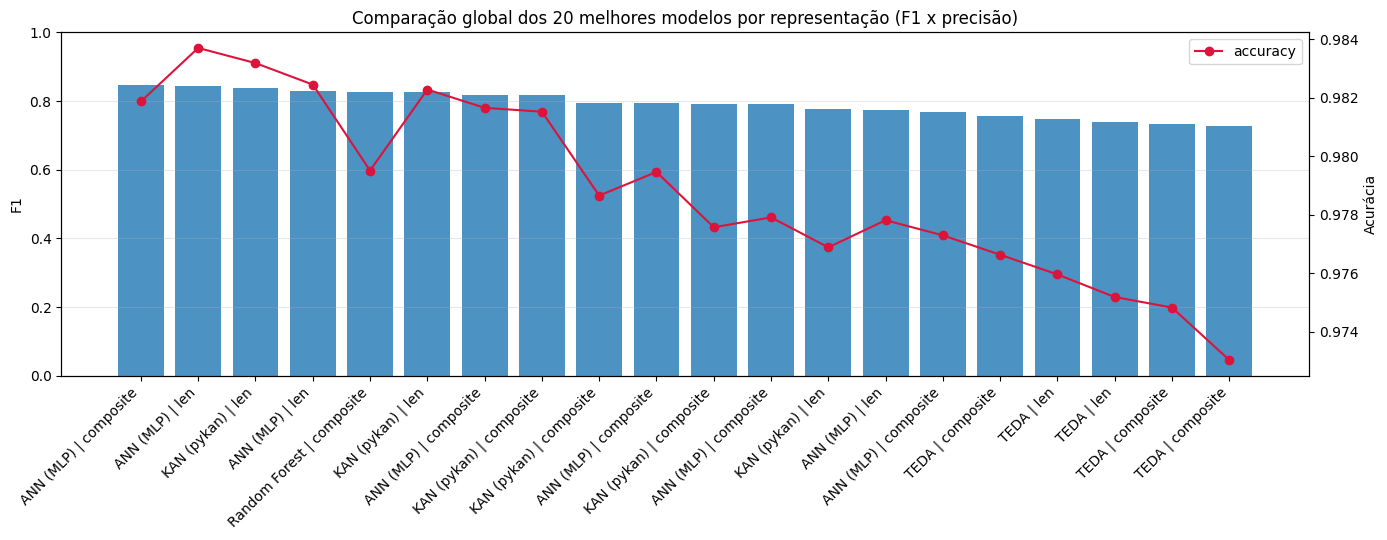

In [37]:
# Plot comparativo simples (F1 e accuracy) por algoritmo/representacao
plot_df = results_globais.dropna(subset=['f1']).copy()
plot_df['modelo_rep'] = plot_df['modelo'] + ' | ' + plot_df['representacao']
plot_df = plot_df.sort_values('f1', ascending=False).head(20)

fig, ax1 = plt.subplots(figsize=(14, 5.5))

x = np.arange(len(plot_df))
ax1.bar(x, plot_df['f1'], alpha=0.8, label='F1')
ax1.set_ylabel('F1')
ax1.set_ylim(0, 1)
ax1.set_xticks(x)
ax1.set_xticklabels(plot_df['modelo_rep'], rotation=45, ha='right')
ax1.grid(True, axis='y', alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(x, plot_df['accuracy'], color='crimson', marker='o', label='accuracy')
ax2.set_ylabel('Acurácia')

ax1.set_title('Comparação global dos 20 melhores modelos por representação (F1 x precisão)')
fig.tight_layout()
plt.legend()
plt.show()

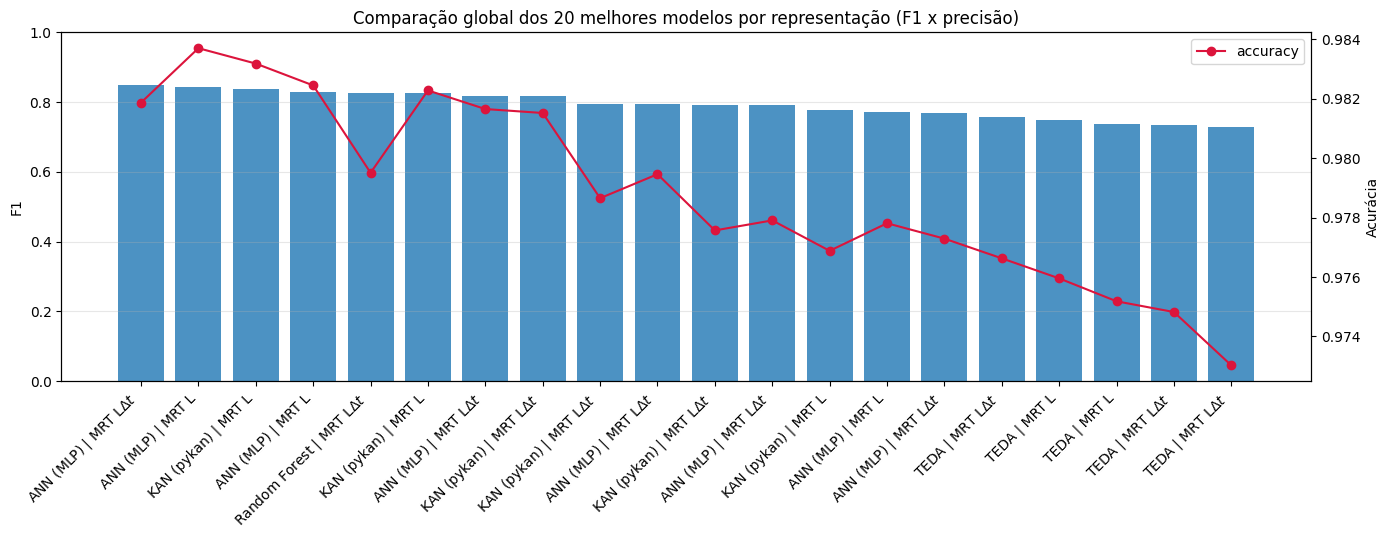

In [38]:
# Plot comparativo simples (F1 e accuracy) por algoritmo/representacao
plot_df = results_globais.dropna(subset=['f1']).copy()

# =========================
# Mapeamento das representações
# =========================
rep_map = {
    'len': r'MRT L',
    'idle': r'MRT $\Delta t$',
    'composite': r'MRT L$\Delta t$'
}

plot_df['representacao'] = plot_df['representacao'].map(rep_map)

# Criar label modelo + representação
plot_df['modelo_rep'] = plot_df['modelo'] + ' | ' + plot_df['representacao']

# Ordenar pelos melhores F1
plot_df = plot_df.sort_values('f1', ascending=False).head(20)

# =========================
# Plot
# =========================
fig, ax1 = plt.subplots(figsize=(14, 5.5))

x = np.arange(len(plot_df))
ax1.bar(x, plot_df['f1'], alpha=0.8, label='F1')
ax1.set_ylabel('F1')
ax1.set_ylim(0, 1)
ax1.set_xticks(x)
ax1.set_xticklabels(plot_df['modelo_rep'], rotation=45, ha='right')
ax1.grid(True, axis='y', alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(x, plot_df['accuracy'], color='crimson', marker='o', label='accuracy')
ax2.set_ylabel('Acurácia')

ax1.set_title('Comparação global dos 20 melhores modelos por representação (F1 x precisão)')
fig.tight_layout()
plt.legend()
plt.show()

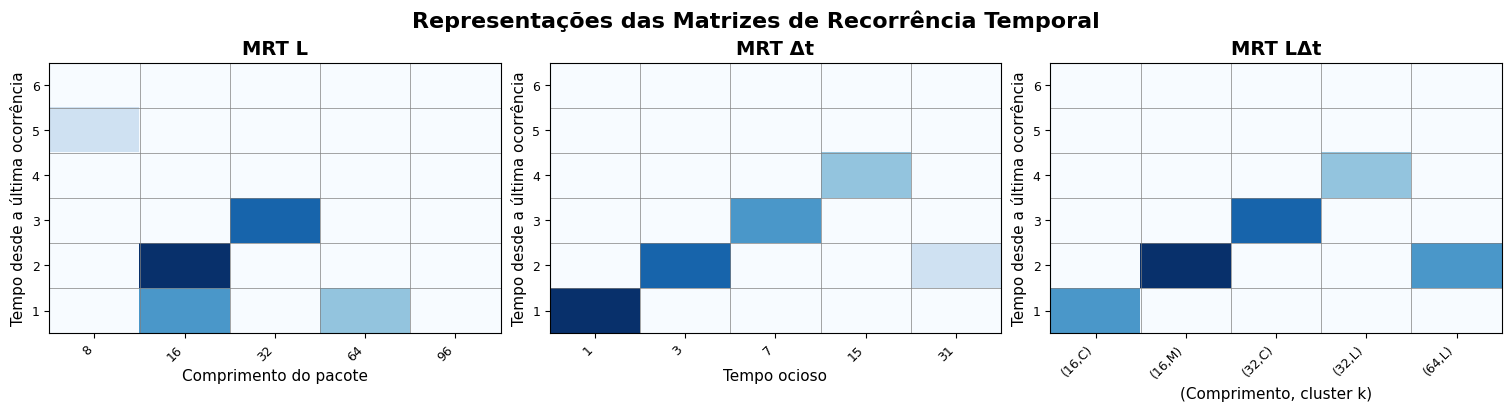

In [35]:
import matplotlib.pyplot as plt
import numpy as np

def draw_matrix(ax, title, xlabel, ylabel, xlabels, highlight_cells):
    # fundo da matriz
    n_rows = 6
    n_cols = len(xlabels)
    mat = np.zeros((n_rows, n_cols))

    # destacar algumas células
    for r, c, val in highlight_cells:
        if 0 <= r < n_rows and 0 <= c < n_cols:
            mat[r, c] = val

    im = ax.imshow(mat, cmap="Blues", origin="lower", aspect="auto")

    # ticks
    ax.set_xticks(range(n_cols))
    ax.set_xticklabels(xlabels, rotation=45, ha="right", fontsize=9)
    ax.set_yticks(range(n_rows))
    ax.set_yticklabels([str(i+1) for i in range(n_rows)], fontsize=9)

    ax.set_title(title, fontsize=14, weight="bold")
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)

    # grade
    ax.set_xticks(np.arange(-.5, n_cols, 1), minor=True)
    ax.set_yticks(np.arange(-.5, n_rows, 1), minor=True)
    ax.grid(which="minor", color="gray", linestyle="-", linewidth=0.5)
    ax.tick_params(which="minor", bottom=False, left=False)

    return im


fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

# 1) MRT L
xlabels_len = ["8", "16", "32", "64", "96"]
highlight_len = [
    (0, 1, 3),
    (1, 1, 5),
    (2, 2, 4),
    (0, 3, 2),
    (4, 0, 1)
]
draw_matrix(
    axes[0],
    "MRT L",
    "Comprimento do pacote",
    "Tempo desde a última ocorrência",
    xlabels_len,
    highlight_len
)

# 2) MRT Δt
xlabels_idle = ["1", "3", "7", "15", "31"]
highlight_idle = [
    (0, 0, 5),
    (1, 1, 4),
    (2, 2, 3),
    (3, 3, 2),
    (1, 4, 1)
]
draw_matrix(
    axes[1],
    "MRT Δt",
    "Tempo ocioso",
    "Tempo desde a última ocorrência",
    xlabels_idle,
    highlight_idle
)

# 3) MRT LΔt
xlabels_comp = ["(16,C)", "(16,M)", "(32,C)", "(32,L)", "(64,L)"]
highlight_comp = [
    (0, 0, 3),
    (1, 1, 5),
    (2, 2, 4),
    (3, 3, 2),
    (1, 4, 3)
]
draw_matrix(
    axes[2],
    "MRT LΔt",
    "(Comprimento, cluster k)",
    "Tempo desde a última ocorrência",
    xlabels_comp,
    highlight_comp
)

fig.suptitle("Representações das Matrizes de Recorrência Temporal", fontsize=16, weight="bold")
plt.show()

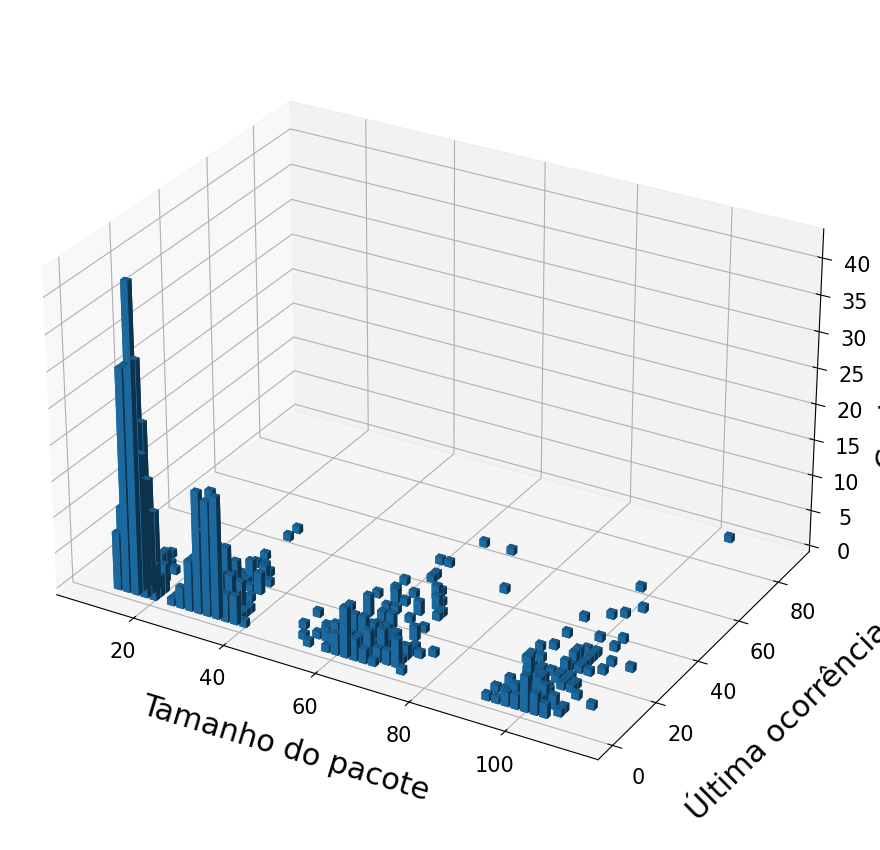

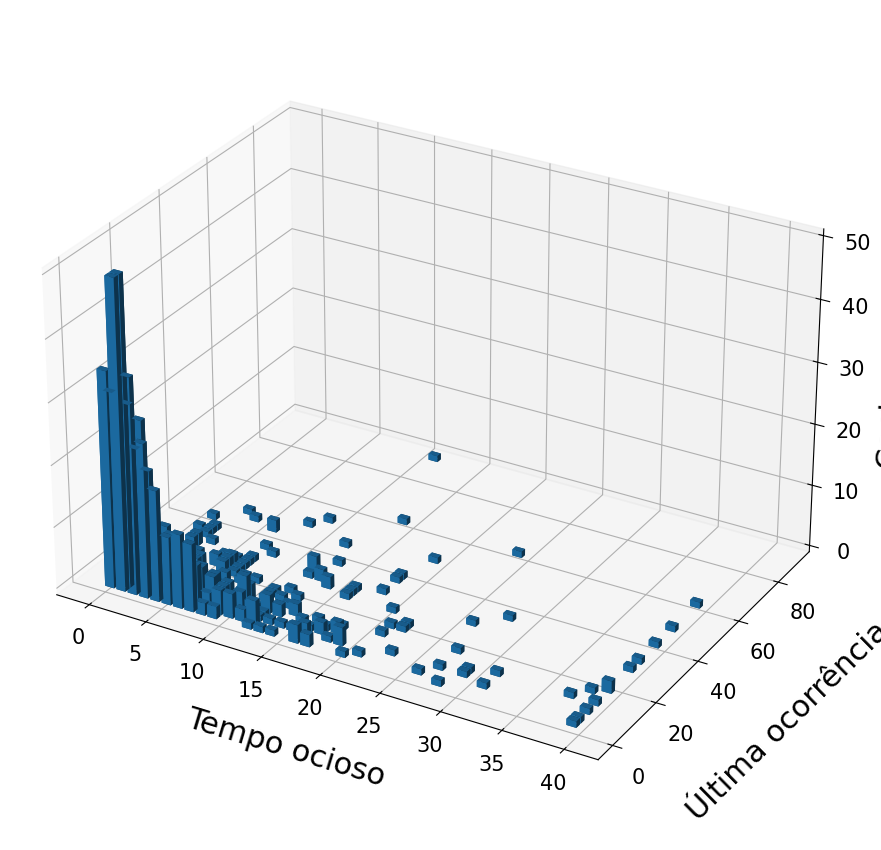

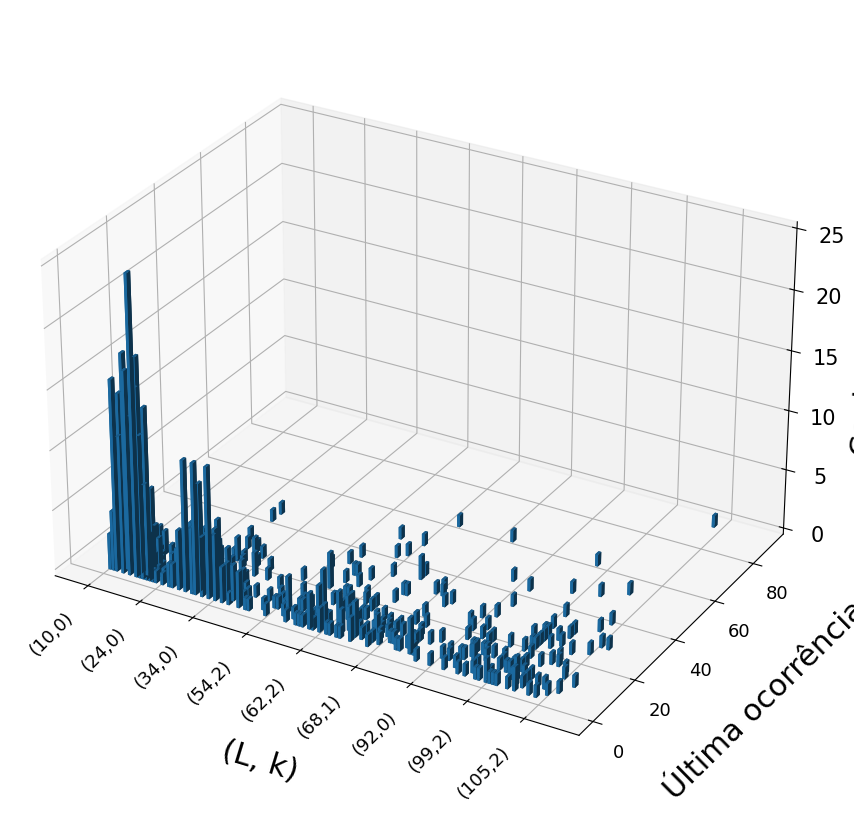

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

np.random.seed(42)

# ===============================
# Gerar um único conjunto de eventos
# ===============================
N = 800

packet_len = np.concatenate([
    np.random.normal(16, 2, 300),
    np.random.normal(32, 3, 250),
    np.random.normal(64, 5, 150),
    np.random.normal(100, 4, 100),
])
packet_len = np.clip(np.round(packet_len), 1, 120)

idle_time = np.concatenate([
    np.random.exponential(2, 400),
    np.random.exponential(6, 250),
    np.random.exponential(12, 150),
])
idle_time = np.clip(np.round(idle_time), 0, 40)

tlo = np.concatenate([
    np.random.exponential(3, 400),
    np.random.exponential(8, 250),
    np.random.exponential(15, 150),
])
tlo = np.clip(np.round(tlo), 0, 90)

m = min(len(packet_len), len(idle_time), len(tlo))
packet_len = packet_len[:m]
idle_time = idle_time[:m]
tlo = tlo[:m]

# ===============================
# Cluster do idle
# ===============================
kmeans = KMeans(n_clusters=3, random_state=0, n_init=10)
k_idle = kmeans.fit_predict(idle_time.reshape(-1, 1))

# ===============================
# Construir representação composta
# ===============================
pairs = list(zip(packet_len.astype(int), k_idle.astype(int)))
unique_pairs = sorted(set(pairs))
pair_to_idx = {p: i for i, p in enumerate(unique_pairs)}
x_comp = np.array([pair_to_idx[p] for p in pairs])

# ===============================
# Função geral para histograma 3D
# ===============================
def save_3d_figure(fig, save_path):
    # bbox_inches='tight' com Axes3D pode gerar recortes incorretos ou imagens gigantes.
    fig.savefig(save_path, dpi=300, facecolor='white')


def plot_3d_hist_single(
    x, y, xbins, ybins,
    title, xlabel,
    figsize=(14, 9),
    save_path=None,
    xticks=None,
    xticklabels=None,
    rotation=0,
    xlabel_pad=22,
    bottom_margin=0.12,
    xy_tick_labelsize=15
):
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection='3d')

    hist, xedges, yedges = np.histogram2d(x, y, bins=[xbins, ybins])

    xpos, ypos = np.meshgrid(xedges[:-1], yedges[:-1], indexing="ij")
    xpos = xpos.ravel()
    ypos = ypos.ravel()
    zpos = np.zeros_like(xpos)

    dx = np.diff(xedges)[0] * np.ones_like(xpos) * 0.8
    dy = np.diff(yedges)[0] * np.ones_like(ypos) * 0.8
    dz = hist.ravel()

    mask = dz > 0
    xpos, ypos, zpos = xpos[mask], ypos[mask], zpos[mask]
    dx, dy, dz = dx[mask], dy[mask], dz[mask]

    ax.bar3d(xpos, ypos, zpos, dx, dy, dz, shade=True)

    # ax.set_title(title, fontsize=18, pad=25)
    ax.set_xlabel(xlabel, fontsize=22, labelpad=xlabel_pad)
    ax.set_ylabel("Última ocorrência", fontsize=22, labelpad=24)
    ax.set_zlabel("Contagem", fontsize=22, labelpad=10)

    ax.tick_params(axis='both', labelsize=xy_tick_labelsize, pad=6)
    ax.tick_params(axis='z', labelsize=15, pad=6)

    if xticks is not None:
        ax.set_xticks(xticks)
    if xticklabels is not None:
        ax.set_xticklabels(xticklabels, rotation=rotation, ha='right')

    ax.view_init(elev=28, azim=-60)
    ax.set_box_aspect((1.35, 1.0, 0.8))

    # Ajuste fino das margens da figura
    fig.subplots_adjust(
        left=0.10,
        right=0.94,
        bottom=bottom_margin,
        top=0.95
    )

    if save_path:
        save_3d_figure(fig, save_path)

    plt.show()


# =====================================================
# Figura 1: MRT L
# =====================================================
plot_3d_hist_single(
    x=packet_len,
    y=tlo,
    xbins=np.arange(0, 121, 2),
    ybins=np.arange(0, 91, 2),
    title="MRT L",
    xlabel="Tamanho do pacote",
    figsize=(14, 10),
    save_path="mrt_len.png"
)

# =====================================================
# Figura 2: MRT Δt
# =====================================================
plot_3d_hist_single(
    x=idle_time,
    y=tlo,
    xbins=np.arange(0, 41, 1),
    ybins=np.arange(0, 91, 2),
    title="MRT Δt",
    xlabel="Tempo ocioso",
    figsize=(14, 10),
    save_path="mrt_idle.png"
)

# =====================================================
# Figura 3: MRT LΔt
# =====================================================
tick_positions = np.arange(len(unique_pairs)) + 0.4
tick_labels = [f"({p[0]},{p[1]})" for p in unique_pairs]

n_labels = 8
step = max(1, len(tick_positions) // n_labels)

plot_3d_hist_single(
    x=x_comp,
    y=tlo,
    xbins=np.arange(0, len(unique_pairs) + 1, 1),
    ybins=np.arange(0, 91, 2),
    title="MRT LΔt",
    xlabel="(L, k)",
    xticks=tick_positions[::step],
    xticklabels=tick_labels[::step],
    rotation=45,
    xlabel_pad=42,
    bottom_margin=0.22,
    xy_tick_labelsize=13,
    figsize=(15, 11),
    save_path="mrt_composite.png"
)